# **OpenLCA resuls analysis**

#### **Setup Data Analyse**

**Open libraries**

In [26]:
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

**Open database**

In [27]:
ROOT = Path(r"C:\Claude\Projects\AR_DPP\LCA_Analysis")

if not (ROOT / "Outputs").is_dir():                 # fallback: search upwards
    here = Path.cwd()
    for cand in [here, *here.parents]:
        if (cand / "Outputs" / "3_impact_assessment").is_dir():
            ROOT = cand
            break

OUT  = ROOT / "Outputs"
BASE = OUT / "3_impact_assessment"
MC   = OUT / "4_monte_carlo"
FIGS = ROOT / "LCA_Notebook" / "figures"            # charts are saved here
FIGS.mkdir(parents=True, exist_ok=True)

print("project root :", ROOT)
print("figures ->   :", FIGS)

project root : C:\Claude\Projects\AR_DPP\LCA_Analysis
figures ->   : C:\Claude\Projects\AR_DPP\LCA_Analysis\LCA_Notebook\figures


In [86]:
BASE_FILES = {
    "EF 3.1":              BASE / "impact_EF31.csv",
    "ReCiPe midpoint (H)": BASE / "impact_ReCiPe_mid.csv",
    "ReCiPe endpoint (H,A)": BASE / "impact_ReCiPe_end.csv",
}

**Setup chart config**

In [28]:
# --- chart styling ----------------------------------------------------------
# Scenarios Sc1..Sc4 are an ORDERED progression (increasing circularity), so they
# get one hue from light to dark. That ordering survives a black-and-white print,
# which a four-colour palette would not.
SC_COLOR = {"sc1": "#b8d3ea", "sc2": "#6fa3d2", "sc3": "#2f6aa6", "sc4": "#16406b"}
SC_NAME  = {"sc1": "Sc1 landfill", "sc2": "Sc2 bulk WEEE",
            "sc3": "Sc3 guided dismantling", "sc4": "Sc4 guided + reuse"}
SCEN     = ["sc1", "sc2", "sc3", "sc4"]

# For things that are identities rather than an order (gross vs credit, EF vs
# ReCiPe, the three areas of protection). Colour-blind safe.
BLUE, AMBER, GREEN = "#0072B2", "#E69F00", "#009E73"

plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 300, "savefig.bbox": "tight",
    "font.family": "serif", "font.size": 9,
    "axes.titlesize": 10, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": "#dcdcdc", "grid.linewidth": 0.6,
    "axes.axisbelow": True, "legend.frameon": False,
    "figure.facecolor": "white", "axes.facecolor": "white",
})

def save(fig, name):
    """Save a chart as PNG (for Word) and PDF (vector, for the final print)."""
    for ext in ("png", "pdf"):
        fig.savefig(FIGS / f"{name}.{ext}")
    print(f"saved: {name}.png / .pdf")


# --- shared helpers ----------------------------------------------------------
# The three categories the screening selects. Defined here so the charts stay
# focused and every part of the notebook names them the same way.
REPORTING = ["Resource use minerals and metals", "Climate change",
             "Eutrophication freshwater"]

def wrap(s, w=24):
    """Break a long category name onto several lines so panel titles don't
    collide with the neighbouring panel."""
    words, lines, cur = s.split(), [], ""
    for x in words:
        if len(cur) + len(x) + 1 > w and cur:
            lines.append(cur); cur = x
        else:
            cur = f"{cur} {x}".strip()
    lines.append(cur)
    return "\n".join(lines)

def sig(v, n=3):
    """n significant digits, keeping trailing zeros so bar labels line up."""
    import math
    if v == 0 or not np.isfinite(v):
        return "0"
    d = n - 1 - math.floor(math.log10(abs(v)))
    return f"{v:.{max(d, 0)}f}"

# **Impact EF3.1 (adapted)**

In [100]:
# --- load the EF3.1 impact table --------------------------------------------
# One row per impact category; columns are gross / saving / net per scenario,
# plus the unit. `category` is the natural index.
ef = pd.read_csv(BASE / "impact_EF31.csv")

UNIT = ef.set_index("category")["unit"]              # keep units aside
ef = ef.set_index("category").drop(columns="unit").astype(float)

print(f"{ef.shape[0]} categories x {ef.shape[1]} columns  <- {BASE / 'impact_EF31.csv'}")
ef.head(10)

25 categories x 10 columns  <- C:\Claude\Projects\AR_DPP\LCA_Analysis\Outputs\3_impact_assessment\impact_EF31.csv


,sc1,sc2_gross,sc2_saving,sc2_net,sc3_gross,sc3_saving,sc3_net,sc4_gross,sc4_saving,sc4_net
category,,,,,,,,,,
Acidification,0.573954,0.574141,0.056551,0.517590,0.574107,0.112018,0.462089,0.574111,0.163262,0.410849
Climate change,73.432586,73.479433,4.418978,69.060455,73.409331,8.162726,65.246605,73.410318,15.431529,57.978789
Climate change (biogenic),0.214481,0.214551,0.015206,0.199345,0.214576,0.025180,0.189396,0.214594,0.039154,0.175440
Climate change (fossil),72.993893,73.040596,4.348220,68.692376,72.970462,8.068483,64.901979,72.971422,15.310760,57.660662
Climate change (land use),0.224211,0.224287,0.055553,0.168734,0.224293,0.069063,0.155229,0.224302,0.081615,0.142687
Ecotoxicity freshwater,1451.953396,1452.164679,128.435253,1323.729426,1452.139627,413.323663,1038.815964,1452.136605,626.126218,826.010386
Ecotoxicity freshwater (inorganics),1433.539557,1433.746086,126.477826,1307.268260,1433.713989,410.360142,1023.353846,1433.711513,620.808990,812.902524
Ecotoxicity freshwater (organics),18.413839,18.418593,1.957427,16.461166,18.425639,2.963521,15.462118,18.425091,5.317229,13.107863
Eutrophication freshwater,0.115920,0.115935,0.006899,0.109036,0.115929,0.019143,0.096787,0.115937,0.029761,0.086176


#### Analysing most representatives categories

In [59]:
scr = pd.read_csv(BASE / "impact_screening.csv")

for c in ("in_reporting_set", "goal_pinned"):
    if scr[c].dtype == object:
        scr[c] = scr[c].astype(str).str.strip().str.lower() == "true"
scr = scr.sort_values("share_pct", ascending=False).reset_index(drop=True)

print(f"reporting set covers {scr.loc[scr.in_reporting_set, 'share_pct'].sum():.1f} % "
      f"of the weighted footprint")
scr

reporting set covers 85.7 % of the weighted footprint


,category,weighted_pe,share_pct,cum_pct,in_reporting_set,goal_pinned
0,Resource use minerals and metals,0.022237,72.452384,72.452384,True,True
1,Climate change,0.002047,6.671002,79.123386,True,True
2,Eutrophication freshwater,0.002020,6.581230,85.704616,True,False
3,Resource use fossils,0.001305,4.250810,89.955426,False,False
4,Acidification,0.000640,2.086411,92.041838,False,False
5,Ecotoxicity freshwater,0.000492,1.601445,93.643282,False,False
6,Particulate matter,0.000436,1.419454,95.062736,False,False
7,Human toxicity non-cancer,0.000354,1.153024,96.215761,False,False
8,Photochemical ozone formation (human health),0.000293,0.955340,97.171100,False,False
9,Water use,0.000285,0.930024,98.101124,False,False


saved: p2_01_screening_pareto.png / .pdf


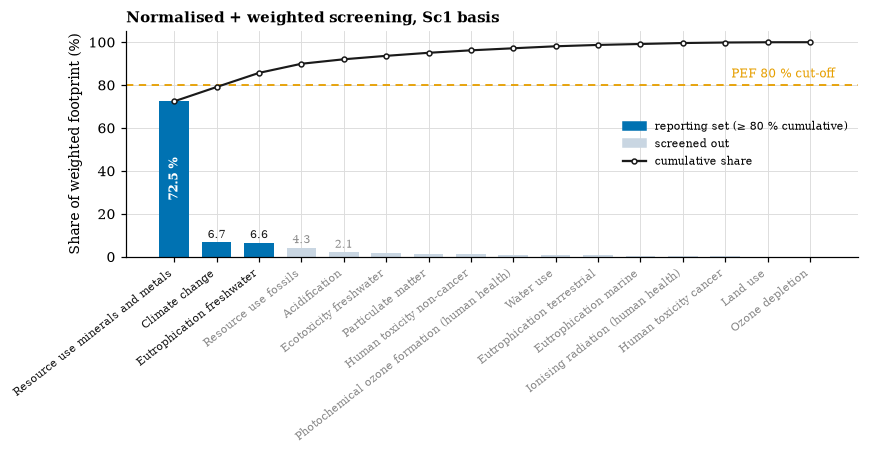

In [60]:
fig, ax = plt.subplots(figsize=(8, 4.2))
x = np.arange(len(scr))
colors = [BLUE if k else "#c9d6e2" for k in scr.in_reporting_set]
bars = ax.bar(x, scr.share_pct, .7, color=colors)

ax.plot(x, scr.cum_pct, color="#1a1a1a", lw=1.4, marker="o", ms=3.2,
        mfc="white", mew=1.0, zorder=5)
ax.axhline(80, color=AMBER, lw=1.2, ls=(0, (4, 3)))
ax.annotate("PEF 80 % cut-off", (len(scr) - .4, 80), (0, 5),
            textcoords="offset points", ha="right", fontsize=8, color=AMBER)

for bar, share, keep in zip(bars, scr.share_pct, scr.in_reporting_set):
    if share >= 25:                      # tall bar: label inside, rotated
        ax.annotate(f"{share:.1f} %", (bar.get_x() + bar.get_width()/2, share/2),
                    ha="center", va="center", rotation=90, fontsize=8,
                    color="white", fontweight="bold")
    elif keep or share >= 2:
        ax.annotate(f"{share:.1f}", (bar.get_x() + bar.get_width()/2, share), (0, 3),
                    textcoords="offset points", ha="center", fontsize=7.5,
                    color="#1a1a1a" if keep else "#8a8a8a")

ax.set_xticks(x); ax.set_xticklabels(scr.category, rotation=38, ha="right", fontsize=7.5)
for t, keep in zip(ax.get_xticklabels(), scr.in_reporting_set):
    t.set_color("#1a1a1a" if keep else "#8a8a8a")
ax.set_ylabel("Share of weighted footprint (%)"); ax.set_ylim(0, 105)

handles = [plt.Rectangle((0, 0), 1, 1, color=BLUE),
           plt.Rectangle((0, 0), 1, 1, color="#c9d6e2"),
           plt.Line2D([0], [0], color="#1a1a1a", marker="o", ms=3.2, mfc="white")]
ax.legend(handles, ["reporting set (≥ 80 % cumulative)", "screened out",
                    "cumulative share"], loc="center right", fontsize=7.5)
ax.set_title("Normalised + weighted screening, Sc1 basis")
fig.tight_layout(); save(fig, "p2_01_screening_pareto"); plt.show()

#### Analysing gross scenarios

In [30]:
# --- gross subset: three headline categories, gross columns only -------------
# sc1 is landfill, which has no recovery credit, so its single column IS the
# gross value -- there is no "sc1_gross" to pair with sc2..sc4.
COLS_GROSS = ["sc1", "sc2_gross", "sc3_gross", "sc4_gross"]

ef_gross = ef.loc[REPORTING, COLS_GROSS]

ef_gross

,sc1,sc2_gross,sc3_gross,sc4_gross
category,,,,
Resource use minerals and metals,0.018739,0.018740,0.018739,0.018740
Climate change,73.432586,73.479433,73.409331,73.410318
Eutrophication freshwater,0.115920,0.115935,0.115929,0.115937


saved: ef31_gross_by_scenario.png / .pdf


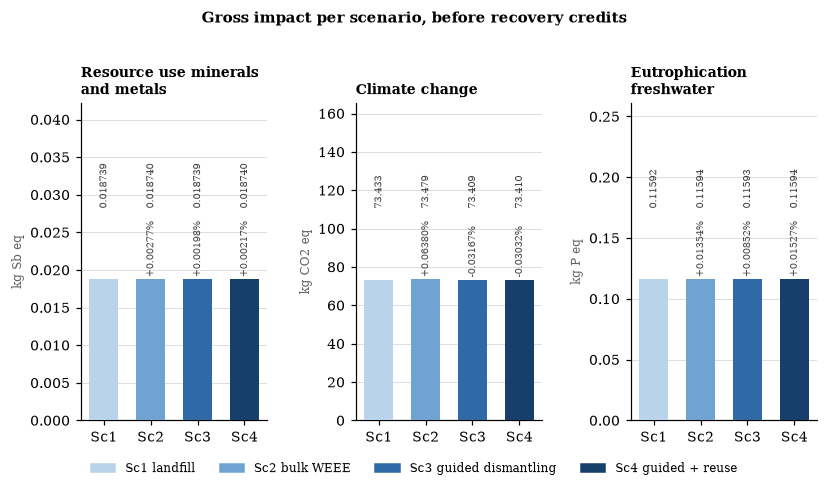

In [44]:
# --- chart: gross impact per scenario ----------------------------------------
# Three categories, three DIFFERENT units (kg Sb eq / kg CO2 eq / kg P eq), so
# they cannot share a y-axis -- small multiples, one panel and one scale each.
scen = [c.split("_")[0] for c in ef_gross.columns]      # sc1, sc2_gross -> sc2

fig, axes = plt.subplots(1, len(ef_gross), figsize=(7.6, 4.0))

for ax, cat in zip(axes, ef_gross.index):
    vals = ef_gross.loc[cat]
    ax.bar(range(len(scen)), vals, width=0.62,
           color=[SC_COLOR[s] for s in scen], zorder=3)

    # sig(v, 8) rather than a fixed decimal count: significant digits adapt to
    # each category's magnitude, so Climate change gets 6 decimals and Resource
    # use gets 9 -- 8 s.f. is the first precision that separates all four
    # scenarios in EVERY panel. Under it, the change vs Sc1 (the baseline).
    # 3 dp on the % because these gross gaps are ~0.03-0.06 %; the usual +.1f
    # would round every panel to +0.0 %.
    base = vals.iloc[0]
    for x, (s, v) in enumerate(zip(scen, vals)):
        ax.annotate(sig(v, 5), (x, v), (0, 48), textcoords="offset points",
                    ha="center", rotation=90, fontsize=6.5, color="#444")
        if s != "sc1":
            ax.annotate(f"{v / base - 1:+.5%}", (x, v), (0, 3),
                        textcoords="offset points", ha="center", rotation=90,
                        fontsize=6.5, color="#4d4d4d")

    ax.set_title(wrap(cat), fontsize=9, pad=6)
    ax.set_ylabel(UNIT[cat], fontsize=8, color="#666")
    ax.set_xticks(range(len(scen)))
    ax.set_xticklabels([s.replace("sc", "Sc") for s in scen])
    ax.set_ylim(0, vals.max() * 2.25)   # bars start at zero; headroom for labels
    ax.grid(axis="x", visible=False)

handles = [plt.Rectangle((0, 0), 1, 1, color=SC_COLOR[s]) for s in scen]
fig.legend(handles, [SC_NAME[s] for s in scen], loc="lower center",
           ncol=4, bbox_to_anchor=(0.5, -0.06), fontsize=8)
fig.suptitle("Gross impact per scenario, before recovery credits",
             x=0.5, y=1.02, fontsize=10, fontweight="bold")
fig.tight_layout(w_pad=2.0)

save(fig, "ef31_gross_by_scenario")
plt.show()

#### Analysing savings scenario

In [51]:
# --- saving subset: three headline categories, saving columns only -------------
# sc1 is landfill, which has no recovery credit, so its single column IS the
# saving value -- there is no "sc1_saving" to pair with sc2..sc4.
COLS_saving = ["sc2_saving", "sc3_saving", "sc4_saving"]

ef_saving = ef.loc[REPORTING, COLS_saving]

ef_saving

,sc2_saving,sc3_saving,sc4_saving
category,,,
Resource use minerals and metals,0.001872,0.006026,0.008870
Climate change,4.418978,8.162726,15.431529
Eutrophication freshwater,0.006899,0.019143,0.029761


saved: ef31_saving_by_scenario.png / .pdf


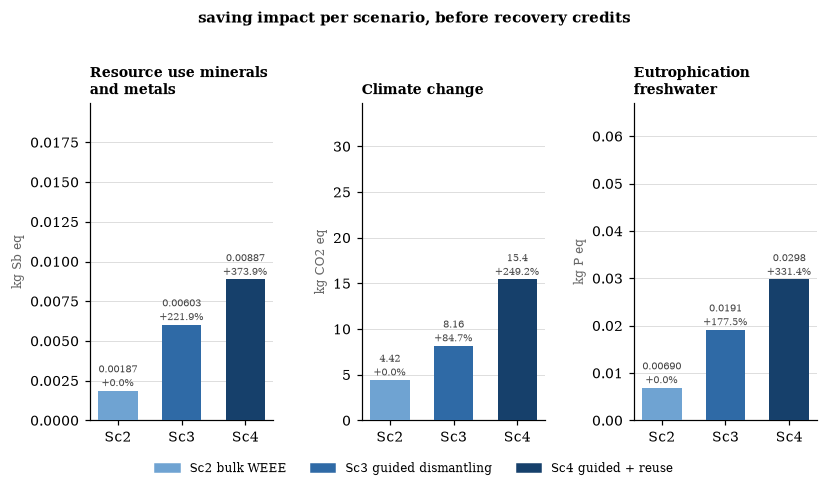

In [52]:
# --- chart: saving impact per scenario ----------------------------------------
# Three categories, three DIFFERENT units (kg Sb eq / kg CO2 eq / kg P eq), so
# they cannot share a y-axis -- small multiples, one panel and one scale each.
scen = [c.split("_")[0] for c in ef_saving.columns]      # sc1, sc2_saving -> sc2

fig, axes = plt.subplots(1, len(ef_saving), figsize=(7.6, 4.0))

for ax, cat in zip(axes, ef_saving.index):
    vals = ef_saving.loc[cat]
    ax.bar(range(len(scen)), vals, width=0.62,
           color=[SC_COLOR[s] for s in scen], zorder=3)

    # sig(v, 8) rather than a fixed decimal count: significant digits adapt to
    # each category's magnitude, so Climate change gets 6 decimals and Resource
    # use gets 9 -- 8 s.f. is the first precision that separates all four
    # scenarios in EVERY panel. Under it, the change vs Sc1 (the baseline).
    # 3 dp on the % because these saving gaps are ~0.03-0.06 %; the usual +.1f
    # would round every panel to +0.0 %.
    base = vals.iloc[0]
    for x, (s, v) in enumerate(zip(scen, vals)):
        ax.annotate(sig(v, 3), (x, v), (0, 12), textcoords="offset points",
                    ha="center", fontsize=6.5, color="#444")
        if s != "sc1":
            ax.annotate(f"{v / base - 1:+.1%}", (x, v), (0, 3),
                        textcoords="offset points", ha="center",
                        fontsize=6.5, color="#4d4d4d")

    ax.set_title(wrap(cat), fontsize=9, pad=6)
    ax.set_ylabel(UNIT[cat], fontsize=8, color="#666")
    ax.set_xticks(range(len(scen)))
    ax.set_xticklabels([s.replace("sc", "Sc") for s in scen])
    ax.set_ylim(0, vals.max() * 2.25)   # bars start at zero; headroom for labels
    ax.grid(axis="x", visible=False)

handles = [plt.Rectangle((0, 0), 1, 1, color=SC_COLOR[s]) for s in scen]
fig.legend(handles, [SC_NAME[s] for s in scen], loc="lower center",
           ncol=4, bbox_to_anchor=(0.5, -0.06), fontsize=8)
fig.suptitle("saving impact per scenario, before recovery credits",
             x=0.5, y=1.02, fontsize=10, fontweight="bold")
fig.tight_layout(w_pad=2.0)

save(fig, "ef31_saving_by_scenario")
plt.show()

#### Analysing net scenario

In [57]:
# --- net subset: three headline categories, net columns only -------------
# sc1 is landfill, which has no recovery credit, so its single column IS the
# net value -- there is no "sc1_net" to pair with sc2..sc4.
COLS_net = ["sc1", "sc2_net", "sc3_net", "sc4_net"]

ef_net = ef.loc[REPORTING, COLS_net]

ef_net

,sc1,sc2_net,sc3_net,sc4_net
category,,,,
Resource use minerals and metals,0.018739,0.016868,0.012714,0.009869
Climate change,73.432586,69.060455,65.246605,57.978789
Eutrophication freshwater,0.115920,0.109036,0.096787,0.086176


saved: ef31_net_by_scenario.png / .pdf


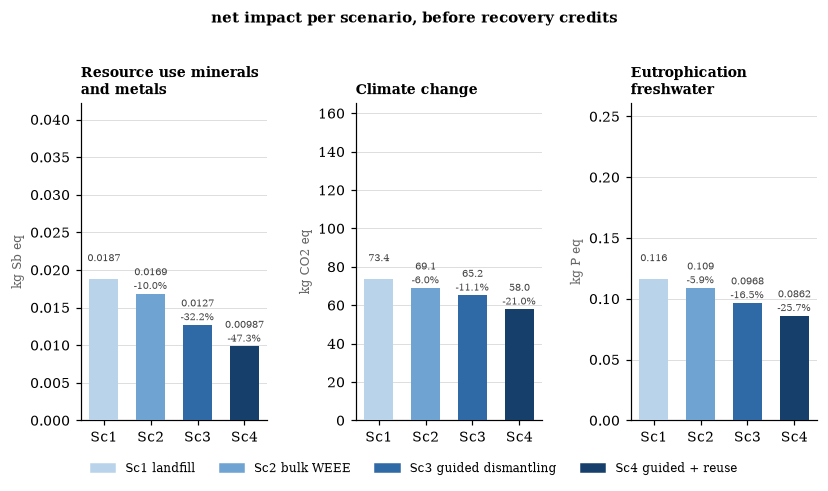

In [58]:
# --- chart: net impact per scenario ----------------------------------------
# Three categories, three DIFFERENT units (kg Sb eq / kg CO2 eq / kg P eq), so
# they cannot share a y-axis -- small multiples, one panel and one scale each.
scen = [c.split("_")[0] for c in ef_net.columns]      # sc1, sc2_net -> sc2

fig, axes = plt.subplots(1, len(ef_net), figsize=(7.6, 4.0))

for ax, cat in zip(axes, ef_net.index):
    vals = ef_net.loc[cat]
    ax.bar(range(len(scen)), vals, width=0.62,
           color=[SC_COLOR[s] for s in scen], zorder=3)

    # sig(v, 8) rather than a fixed decimal count: significant digits adapt to
    # each category's magnitude, so Climate change gets 6 decimals and Resource
    # use gets 9 -- 8 s.f. is the first precision that separates all four
    # scenarios in EVERY panel. Under it, the change vs Sc1 (the baseline).
    # 3 dp on the % because these net gaps are ~0.03-0.06 %; the usual +.1f
    # would round every panel to +0.0 %.
    base = vals.iloc[0]
    for x, (s, v) in enumerate(zip(scen, vals)):
        ax.annotate(sig(v, 3), (x, v), (0, 12), textcoords="offset points",
                    ha="center", fontsize=6.5, color="#444")
        if s != "sc1":
            ax.annotate(f"{v / base - 1:+.1%}", (x, v), (0, 3),
                        textcoords="offset points", ha="center",
                        fontsize=6.5, color="#4d4d4d")

    ax.set_title(wrap(cat), fontsize=9, pad=6)
    ax.set_ylabel(UNIT[cat], fontsize=8, color="#666")
    ax.set_xticks(range(len(scen)))
    ax.set_xticklabels([s.replace("sc", "Sc") for s in scen])
    ax.set_ylim(0, vals.max() * 2.25)   # bars start at zero; headroom for labels
    ax.grid(axis="x", visible=False)

handles = [plt.Rectangle((0, 0), 1, 1, color=SC_COLOR[s]) for s in scen]
fig.legend(handles, [SC_NAME[s] for s in scen], loc="lower center",
           ncol=4, bbox_to_anchor=(0.5, -0.06), fontsize=8)
fig.suptitle("net impact per scenario, before recovery credits",
             x=0.5, y=1.02, fontsize=10, fontweight="bold")
fig.tight_layout(w_pad=2.0)

save(fig, "ef31_net_by_scenario")
plt.show()

**Net reduction vs Sc1 — all 25 categories**

saved: ef31_reduction_heatmap.png / .pdf


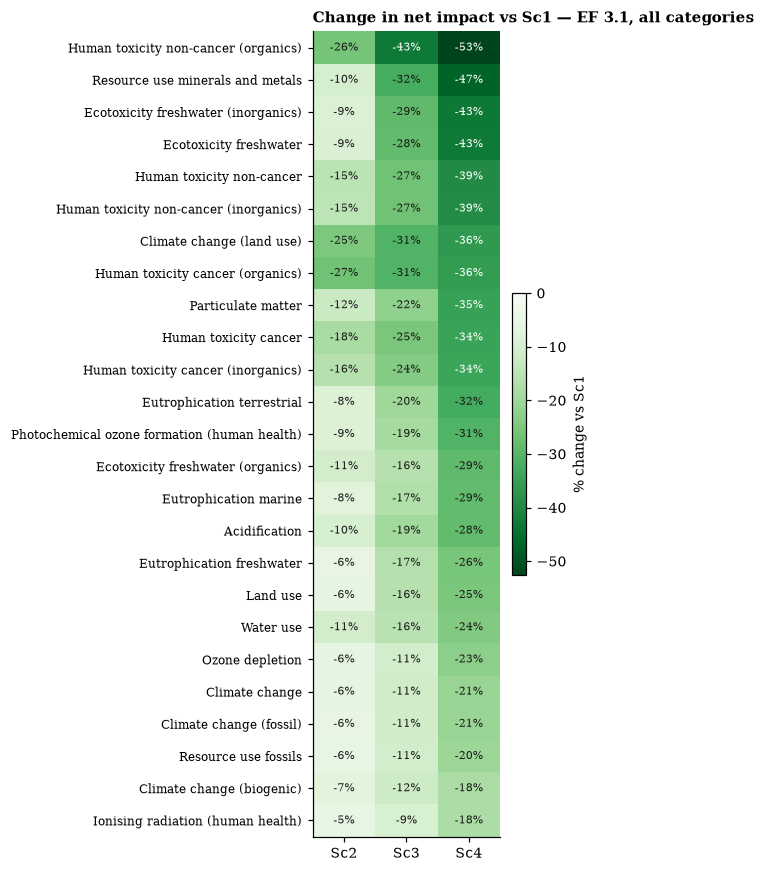

In [55]:
# --- heat map: net change vs Sc1, every category ------------------------------
# Percentages are unitless, so unlike the bar chart above all 25 categories CAN
# share one scale. Sc1 is the baseline and would be a column of zeros, so only
# Sc2..Sc4 are drawn.
NET = ["sc2", "sc3", "sc4"]

pct = pd.DataFrame({sc: (ef[f"{sc}_net"] / ef["sc1"] - 1) * 100 for sc in NET})
pct = pct.sort_values("sc4")            # best performer under Sc4 at the top

fig, ax = plt.subplots(figsize=(5.2, 8))
# Every value is a reduction (-53%..-5%), so this is a one-directional
# magnitude scale: a single hue, light -> dark. vmax=0 anchors "no change" to
# white. Re-check that if a category ever comes out positive -- it would clip.
im = ax.imshow(pct.values, cmap="Greens_r", aspect="auto",
               vmin=pct.values.min(), vmax=0)

for i in range(pct.shape[0]):
    for j in range(pct.shape[1]):
        v = pct.values[i, j]
        # Pick the text colour from the cell's own luminance rather than a
        # fixed cut-off, so mid-green cells keep dark text and stay legible.
        r, g, b, _ = im.cmap(im.norm(v))
        lum = 0.299 * r + 0.587 * g + 0.114 * b
        ax.text(j, i, f"{v:.0f}%", ha="center", va="center", fontsize=7.5,
                color="white" if lum < 0.5 else "#1a1a1a")

ax.set_xticks(range(len(NET)))
ax.set_xticklabels([s.replace("sc", "Sc") for s in NET])
ax.set_yticks(range(len(pct)))
ax.set_yticklabels(pct.index, fontsize=8)
ax.set_title("Change in net impact vs Sc1 — EF 3.1, all categories")
ax.grid(False)
fig.colorbar(im, ax=ax, shrink=.35, label="% change vs Sc1")
fig.tight_layout()

save(fig, "ef31_reduction_heatmap")
plt.show()

#### **Where the reduction comes from — gross split into net and credit**

saved: ef31_gross_vs_credit.png / .pdf


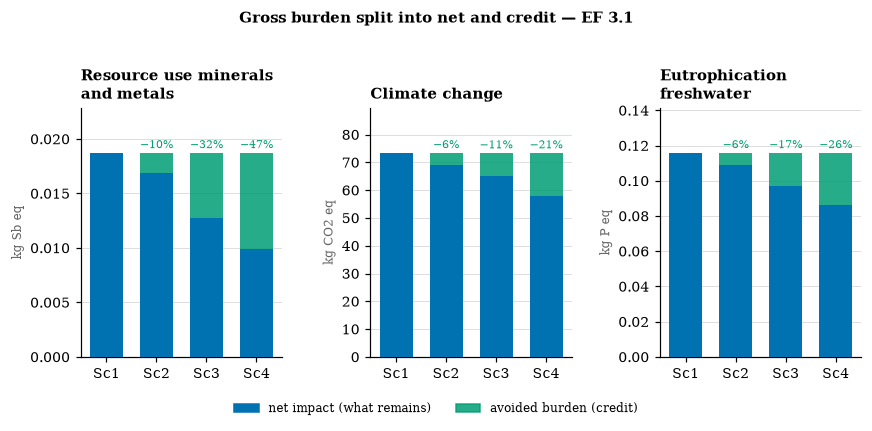

In [56]:
# --- chart: gross burden split into net + credit ------------------------------
# Each bar totals the GROSS value (verified: gross - saving == net for all 25
# categories). Blue is what remains, green is the recovery credit -- so this is
# the same gross bar as further up, now cut to show where the reduction comes
# from. Sc1 is landfill: no credit, so the bar is entirely blue.
fig, axes = plt.subplots(1, len(REPORTING), figsize=(8.0, 3.4))

for ax, cat in zip(axes, REPORTING):
    r = ef.loc[cat]
    nets = np.array([r["sc1"]] + [r[f"{sc}_net"]    for sc in SCEN[1:]])
    sav  = np.array([0.0]      + [r[f"{sc}_saving"] for sc in SCEN[1:]])

    ax.bar(range(4), nets, .66, color=BLUE, zorder=3)
    ax.bar(range(4), sav, .66, bottom=nets, color=GREEN, alpha=.85, zorder=3)

    # Credit as a share of gross -- i.e. the reduction vs that scenario's own
    # gross bar. Sc1 has no credit, so it gets no label.
    for i, (n, s) in enumerate(zip(nets, sav)):
        if s > 0:
            ax.annotate(f"−{s / (n + s) * 100:.0f}%", (i, n + s), (0, 3),
                        textcoords="offset points", ha="center",
                        fontsize=7.5, color=GREEN)

    ax.set_title(wrap(cat))
    ax.set_ylabel(UNIT[cat], fontsize=8, color="#666")
    ax.set_xticks(range(4))
    ax.set_xticklabels([s.replace("sc", "Sc") for s in SCEN])
    ax.set_ylim(0, (nets + sav).max() * 1.22)
    ax.grid(axis="x", visible=False)

handles = [plt.Rectangle((0, 0), 1, 1, color=BLUE),
           plt.Rectangle((0, 0), 1, 1, color=GREEN, alpha=.85)]
fig.legend(handles, ["net impact (what remains)", "avoided burden (credit)"],
           loc="lower center", ncol=2, bbox_to_anchor=(.5, -.08), fontsize=8)
fig.suptitle("Gross burden split into net and credit — EF 3.1",
             x=0.5, y=1.03, fontsize=10, fontweight="bold")
fig.tight_layout(w_pad=2.0)

save(fig, "ef31_gross_vs_credit")
plt.show()

## **Monte Carlo — does the deterministic run sit at the centre?**

#####  Load the Monte Carlo draws 

In [34]:
SYSTEMS = ["Sc1", "Sc2g", "Sc2s", "Sc3g", "Sc3s", "Sc4g", "Sc4s"]

runs = {}
for k in SYSTEMS:
    p = MC / f"mc_raw_{k}.csv"
    if p.exists():
        runs[k] = pd.read_csv(p).set_index("iteration")

missing = [k for k in SYSTEMS if k not in runs]
print("exports found :", ", ".join(runs) or "none")
print("still missing :", ", ".join(missing) or "none - all seven complete")
if runs:
    k0 = next(iter(runs))
    print(f"\n{k0}: {runs[k0].shape[0]} runs x {runs[k0].shape[1]} categories")

exports found : Sc1, Sc2g, Sc2s, Sc3g, Sc3s, Sc4g, Sc4s
still missing : none - all seven complete

Sc1: 1000 runs x 25 categories


#### Deterministic vs Monte Carlo, Sc1 

In [61]:

# `ef` here is WIDE (one row per category), so there is no .scenario column to
# filter on -- the Sc1 net is simply the "sc1" column. Landfill earns no
# recovery credit, so for Sc1 net == gross == sc1.
if "Sc1" in runs:
    det = ef["sc1"]
    rows = []
    for c in REPORTING:
        if c in runs["Sc1"]:
            s = runs["Sc1"][c]
            rows.append({"category": c, "unit": UNIT[c],
                         "deterministic (mode-based)": det[c],
                         "MC mean": s.mean(),
                         #"MC median": s.median(),
                         "MC mean / deterministic": f"{s.mean() / det[c]:.2f}×",
                         #"MC p5": s.quantile(.05),
                         #"MC p95": s.quantile(.95)
                         })
    display(pd.DataFrame(rows))
else:
    print("Sc1 export not available yet.")

,category,unit,deterministic (mode-based),MC mean,MC mean / deterministic
0,Resource use minerals and metals,kg Sb eq,0.018739,0.018950,1.01×
1,Climate change,kg CO2 eq,73.432586,94.380511,1.29×
2,Eutrophication freshwater,kg P eq,0.115920,0.149132,1.29×


saved: ef31_mc_distribution_sc1_all.png / .pdf


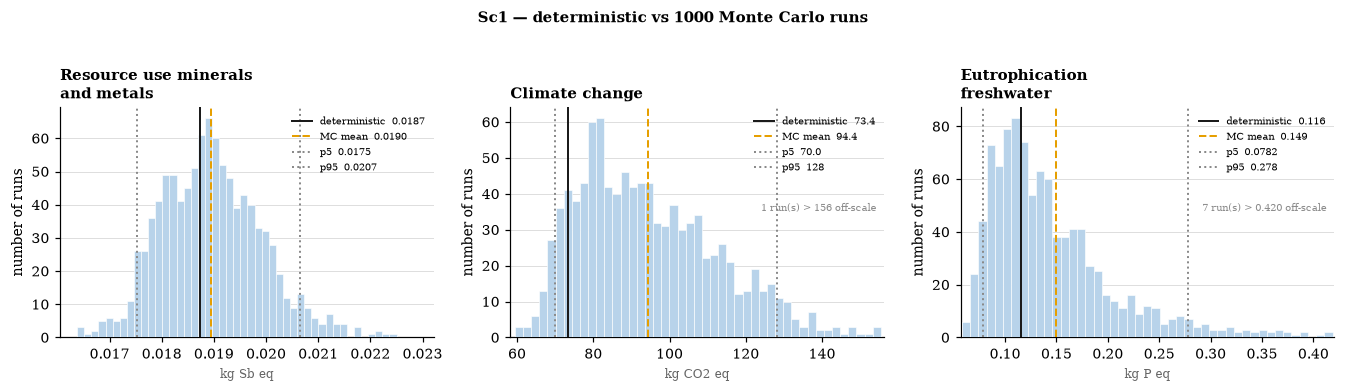

In [78]:
# --- Sc1: deterministic vs Monte Carlo, all three reporting categories --------
# One panel per category. Each has its OWN x-axis: the three categories are in
# kg Sb eq / kg CO2 eq / kg P eq and differ by orders of magnitude, so a shared
# scale is impossible.
CATS_MC = REPORTING          # reorder here if you want a different panel order

if "Sc1" in runs:
    cats = [c for c in CATS_MC if c in runs["Sc1"]]

    fig, axes = plt.subplots(1, len(cats), figsize=(4.1 * len(cats), 3.4))
    axes = np.atleast_1d(axes)          # keeps zip() working if cats has 1 entry

    for ax, cat in zip(axes, cats):
        s = runs["Sc1"][cat]
        # WIDE table: no .scenario/.category columns to filter on, and Sc1's net
        # is the "sc1" column (landfill earns no credit, so net == gross == sc1).
        det_val = ef.loc[cat, "sc1"]

        # Eutrophication has one draw at 2.19 kg P eq, ~8x its own p95, which
        # squashes the whole distribution into the left edge. Clip the axis at
        # p99 and say how many runs fall outside rather than hiding them.
        hi = max(s.quantile(.99), det_val, s.mean()) * 1.08
        shown = s[s <= hi]
        n_hidden = len(s) - len(shown)

        ax.hist(shown, bins=45, color=SC_COLOR["sc1"], edgecolor="white",
                linewidth=.4, zorder=3)
        ax.set_xlim(min(s.min(), det_val) * .98, hi)
        if n_hidden:
            ax.annotate(f"{n_hidden} run(s) > {sig(hi, 3)} off-scale",
                        (.98, .55), xycoords="axes fraction", ha="right",
                        fontsize=6.5, color="#8a8a8a")

        # sig(v, 3), not f"{v:.1f}": Resource use is ~0.0187, so .1f would
        # print "0.0" for every line in that panel.
        for val, color, lab, ls in (
            (det_val,         "#1a1a1a", f"deterministic  {sig(det_val, 3)}", "-"),
            (s.mean(),        AMBER,     f"MC mean  {sig(s.mean(), 3)}",      "--"),
            (s.quantile(.05), "#8a8a8a", f"p5  {sig(s.quantile(.05), 3)}",    ":"),
            (s.quantile(.95), "#8a8a8a", f"p95  {sig(s.quantile(.95), 3)}",   ":"),
        ):
            ax.axvline(val, color=color, ls=ls, lw=1.3, label=lab, zorder=4)

        ax.set_title(wrap(cat))
        # Units from UNIT (the impact CSV) -- runs[...].attrs["units"] only
        # exists on the xlsx-parsed frames, not the mc_raw_*.csv ones.
        ax.set_xlabel(UNIT[cat], fontsize=8, color="#666")
        ax.set_ylabel("number of runs")
        ax.legend(fontsize=6.5, loc="upper right")
        ax.grid(axis="x", visible=False)

    fig.suptitle(f"Sc1 — deterministic vs {len(runs['Sc1'])} Monte Carlo runs",
                 x=0.5, y=1.03, fontsize=10, fontweight="bold")
    fig.tight_layout(w_pad=2.0)

    save(fig, "ef31_mc_distribution_sc1_all")
    plt.show()
else:
    print("Sc1 export not available yet — skipping.")


#### Deterministic vs Monte Carlo, Sc2

##### Deterministic vs Monte Carlo, Sc2 gross

In [74]:
if "Sc2g" in runs:
    det = ef["sc2_gross"]
    rows = []
    for c in REPORTING:
        if c in runs["Sc2g"]:
            s = runs["Sc2g"][c]
            rows.append({"category": c, "unit": UNIT[c],
                         "deterministic (mode-based)": det[c],
                         "MC mean": s.mean(),
                         #"MC median": s.median(),
                         "MC mean / deterministic": f"{s.mean() / det[c]:.2f}×",
                         #"MC p5": s.quantile(.05),
                         #"MC p95": s.quantile(.95)
                         })
    display(pd.DataFrame(rows))
else:
    print("Sc2g export not available yet.")

,category,unit,deterministic (mode-based),MC mean,MC mean / deterministic
0,Resource use minerals and metals,kg Sb eq,0.018740,0.018943,1.01×
1,Climate change,kg CO2 eq,73.479433,92.006242,1.25×
2,Eutrophication freshwater,kg P eq,0.115935,0.145155,1.25×


saved: ef31_mc_distribution_Sc2g_all.png / .pdf


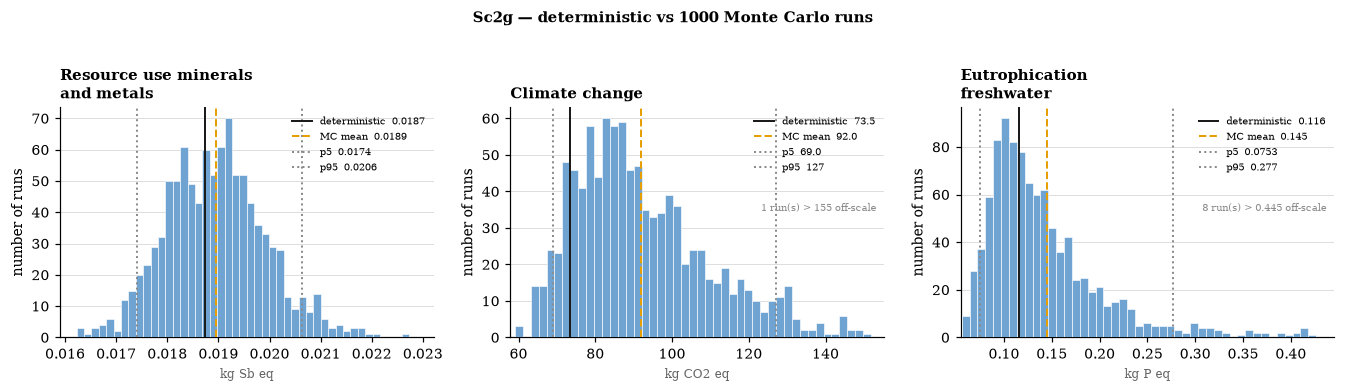

In [75]:
# --- Sc2g: deterministic vs Monte Carlo, all three reporting categories --------
# One panel per category. Each has its OWN x-axis: the three categories are in
# kg Sb eq / kg CO2 eq / kg P eq and differ by orders of magnitude, so a shared
# scale is impossible.
CATS_MC = REPORTING          # reorder here if you want a different panel order

if "Sc2g" in runs:
    cats = [c for c in CATS_MC if c in runs["Sc2g"]]

    fig, axes = plt.subplots(1, len(cats), figsize=(4.1 * len(cats), 3.4))
    axes = np.atleast_1d(axes)          # keeps zip() working if cats has 1 entry

    for ax, cat in zip(axes, cats):
        s = runs["Sc2g"][cat]
        # WIDE table: no .scenario/.category columns to filter on, and Sc2g's net
        # is the "Sc2_gross" column (landfill earns no credit, so net == gross == Sc2_gross).
        det_val = ef.loc[cat, "sc2_gross"]

        # Eutrophication has one draw at 2.19 kg P eq, ~8x its own p95, which
        # squashes the whole distribution into the left edge. Clip the axis at
        # p99 and say how many runs fall outside rather than hiding them.
        hi = max(s.quantile(.99), det_val, s.mean()) * 1.08
        shown = s[s <= hi]
        n_hidden = len(s) - len(shown)

        ax.hist(shown, bins=45, color=SC_COLOR["sc2"], edgecolor="white",
                linewidth=.4, zorder=3)
        ax.set_xlim(min(s.min(), det_val) * .98, hi)
        if n_hidden:
            ax.annotate(f"{n_hidden} run(s) > {sig(hi, 3)} off-scale",
                        (.98, .55), xycoords="axes fraction", ha="right",
                        fontsize=6.5, color="#8a8a8a")

        # sig(v, 3), not f"{v:.1f}": Resource use is ~0.0187, so .1f would
        # print "0.0" for every line in that panel.
        for val, color, lab, ls in (
            (det_val,         "#1a1a1a", f"deterministic  {sig(det_val, 3)}", "-"),
            (s.mean(),        AMBER,     f"MC mean  {sig(s.mean(), 3)}",      "--"),
            (s.quantile(.05), "#8a8a8a", f"p5  {sig(s.quantile(.05), 3)}",    ":"),
            (s.quantile(.95), "#8a8a8a", f"p95  {sig(s.quantile(.95), 3)}",   ":"),
        ):
            ax.axvline(val, color=color, ls=ls, lw=1.3, label=lab, zorder=4)

        ax.set_title(wrap(cat))
        # Units from UNIT (the impact CSV) -- runs[...].attrs["units"] only
        # exists on the xlsx-parsed frames, not the mc_raw_*.csv ones.
        ax.set_xlabel(UNIT[cat], fontsize=8, color="#666")
        ax.set_ylabel("number of runs")
        ax.legend(fontsize=6.5, loc="upper right")
        ax.grid(axis="x", visible=False)

    fig.suptitle(f"Sc2g — deterministic vs {len(runs['Sc2g'])} Monte Carlo runs",
                 x=0.5, y=1.03, fontsize=10, fontweight="bold")
    fig.tight_layout(w_pad=2.0)

    save(fig, "ef31_mc_distribution_Sc2g_all")
    plt.show()
else:
    print("Sc2g export not available yet — skipping.")


##### Deterministic vs Monte Carlo, Sc2 savings

In [67]:
if "Sc2s" in runs:
    det = ef["sc2_saving"]
    rows = []
    for c in REPORTING:
        if c in runs["Sc2s"]:
            s = runs["Sc2s"][c]
            rows.append({"category": c, "unit": UNIT[c],
                         "deterministic (mode-based)": det[c],
                         "MC mean": s.mean(),
                         #"MC median": s.median(),
                         "MC mean / deterministic": f"{s.mean() / det[c]:.2f}×",
                         #"MC p5": s.quantile(.05),
                         #"MC p95": s.quantile(.95)
                         })
    display(pd.DataFrame(rows))
else:
    print("Sc2s export not available yet.")

,category,unit,deterministic (mode-based),MC mean,MC mean / deterministic
0,Resource use minerals and metals,kg Sb eq,0.001872,0.001873,1.00×
1,Climate change,kg CO2 eq,4.418978,4.647598,1.05×
2,Eutrophication freshwater,kg P eq,0.006899,0.006974,1.01×


saved: ef31_mc_distribution_Sc2s_all.png / .pdf


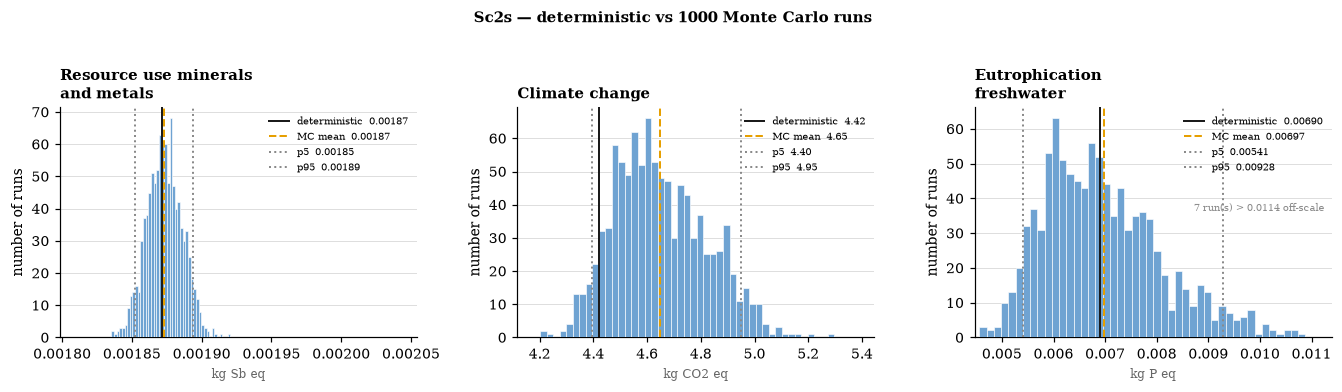

In [70]:
# --- Sc2s: deterministic vs Monte Carlo, all three reporting categories --------
# One panel per category. Each has its OWN x-axis: the three categories are in
# kg Sb eq / kg CO2 eq / kg P eq and differ by orders of magnitude, so a shared
# scale is impossible.
CATS_MC = REPORTING          # reorder here if you want a different panel order

if "Sc2s" in runs:
    cats = [c for c in CATS_MC if c in runs["Sc2s"]]

    fig, axes = plt.subplots(1, len(cats), figsize=(4.1 * len(cats), 3.4))
    axes = np.atleast_1d(axes)          # keeps zip() working if cats has 1 entry

    for ax, cat in zip(axes, cats):
        s = runs["Sc2s"][cat]
        # WIDE table: no .scenario/.category columns to filter on, and Sc2s's net
        # is the "Sc2_saving" column (landfill earns no credit, so net == gross == Sc2_saving).
        det_val = ef.loc[cat, "sc2_saving"]

        # Eutrophication has one draw at 2.19 kg P eq, ~8x its own p95, which
        # squashes the whole distribution into the left edge. Clip the axis at
        # p99 and say how many runs fall outside rather than hiding them.
        hi = max(s.quantile(.99), det_val, s.mean()) * 1.08
        shown = s[s <= hi]
        n_hidden = len(s) - len(shown)

        ax.hist(shown, bins=45, color=SC_COLOR["sc2"], edgecolor="white",
                linewidth=.4, zorder=3)
        ax.set_xlim(min(s.min(), det_val) * .98, hi)
        if n_hidden:
            ax.annotate(f"{n_hidden} run(s) > {sig(hi, 3)} off-scale",
                        (.98, .55), xycoords="axes fraction", ha="right",
                        fontsize=6.5, color="#8a8a8a")

        # sig(v, 3), not f"{v:.1f}": Resource use is ~0.0187, so .1f would
        # print "0.0" for every line in that panel.
        for val, color, lab, ls in (
            (det_val,         "#1a1a1a", f"deterministic  {sig(det_val, 3)}", "-"),
            (s.mean(),        AMBER,     f"MC mean  {sig(s.mean(), 3)}",      "--"),
            (s.quantile(.05), "#8a8a8a", f"p5  {sig(s.quantile(.05), 3)}",    ":"),
            (s.quantile(.95), "#8a8a8a", f"p95  {sig(s.quantile(.95), 3)}",   ":"),
        ):
            ax.axvline(val, color=color, ls=ls, lw=1.3, label=lab, zorder=4)

        ax.set_title(wrap(cat))
        # Units from UNIT (the impact CSV) -- runs[...].attrs["units"] only
        # exists on the xlsx-parsed frames, not the mc_raw_*.csv ones.
        ax.set_xlabel(UNIT[cat], fontsize=8, color="#666")
        ax.set_ylabel("number of runs")
        ax.legend(fontsize=6.5, loc="upper right")
        ax.grid(axis="x", visible=False)

    fig.suptitle(f"Sc2s — deterministic vs {len(runs['Sc2s'])} Monte Carlo runs",
                 x=0.5, y=1.03, fontsize=10, fontweight="bold")
    fig.tight_layout(w_pad=2.0)

    save(fig, "ef31_mc_distribution_Sc2s_all")
    plt.show()
else:
    print("Sc2s export not available yet — skipping.")


#### Deterministic vs Monte Carlo, Sc3

##### Deterministic vs Monte Carlo, Sc3 gross

In [76]:
if "Sc3g" in runs:
    det = ef["sc3_gross"]
    rows = []
    for c in REPORTING:
        if c in runs["Sc3g"]:
            s = runs["Sc3g"][c]
            rows.append({"category": c, "unit": UNIT[c],
                         "deterministic (mode-based)": det[c],
                         "MC mean": s.mean(),
                         #"MC median": s.median(),
                         "MC mean / deterministic": f"{s.mean() / det[c]:.3f}×",
                         #"MC p5": s.quantile(.05),
                         #"MC p95": s.quantile(.95)
                         })
    display(pd.DataFrame(rows))
else:
    print("Sc3g export not available yet.")

,category,unit,deterministic (mode-based),MC mean,MC mean / deterministic
0,Resource use minerals and metals,kg Sb eq,0.018739,0.018956,1.012×
1,Climate change,kg CO2 eq,73.409331,94.546568,1.288×
2,Eutrophication freshwater,kg P eq,0.115929,0.146910,1.267×


saved: ef31_mc_distribution_Sc3g_all.png / .pdf


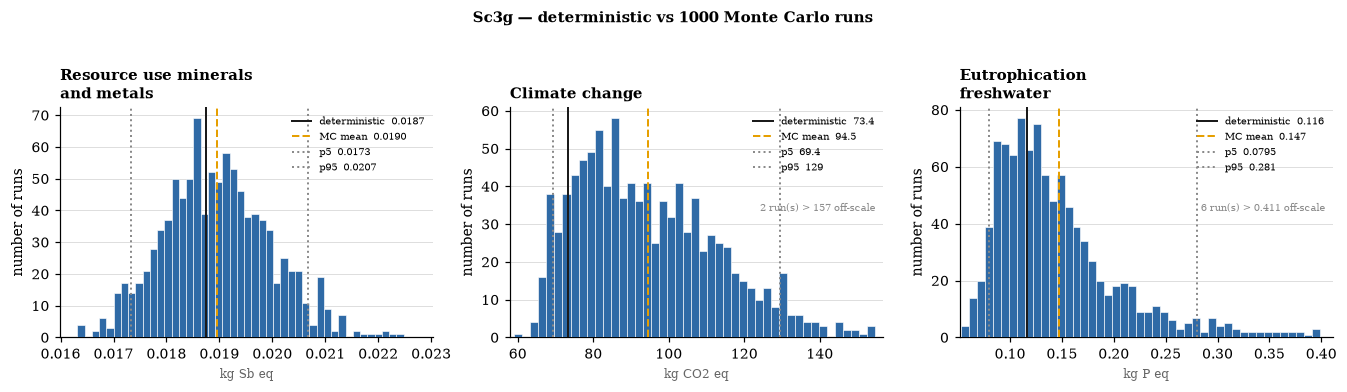

In [77]:
# --- Sc3g: deterministic vs Monte Carlo, all three reporting categories --------
# One panel per category. Each has its OWN x-axis: the three categories are in
# kg Sb eq / kg CO2 eq / kg P eq and differ by orders of magnitude, so a shared
# scale is impossible.
CATS_MC = REPORTING          # reorder here if you want a different panel order

if "Sc3g" in runs:
    cats = [c for c in CATS_MC if c in runs["Sc3g"]]

    fig, axes = plt.subplots(1, len(cats), figsize=(4.1 * len(cats), 3.4))
    axes = np.atleast_1d(axes)          # keeps zip() working if cats has 1 entry

    for ax, cat in zip(axes, cats):
        s = runs["Sc3g"][cat]
        # WIDE table: no .scenario/.category columns to filter on, and Sc3g's net
        # is the "Sc3g" column (landfill earns no credit, so net == gross == Sc3g).
        det_val = ef.loc[cat, "sc3_gross"]

        # Eutrophication has one draw at 2.19 kg P eq, ~8x its own p95, which
        # squashes the whole distribution into the left edge. Clip the axis at
        # p99 and say how many runs fall outside rather than hiding them.
        hi = max(s.quantile(.99), det_val, s.mean()) * 1.08
        shown = s[s <= hi]
        n_hidden = len(s) - len(shown)

        ax.hist(shown, bins=45, color=SC_COLOR["sc3"], edgecolor="white",
                linewidth=.4, zorder=3)
        ax.set_xlim(min(s.min(), det_val) * .98, hi)
        if n_hidden:
            ax.annotate(f"{n_hidden} run(s) > {sig(hi, 3)} off-scale",
                        (.98, .55), xycoords="axes fraction", ha="right",
                        fontsize=6.5, color="#8a8a8a")

        # sig(v, 3), not f"{v:.1f}": Resource use is ~0.0187, so .1f would
        # print "0.0" for every line in that panel.
        for val, color, lab, ls in (
            (det_val,         "#1a1a1a", f"deterministic  {sig(det_val, 3)}", "-"),
            (s.mean(),        AMBER,     f"MC mean  {sig(s.mean(), 3)}",      "--"),
            (s.quantile(.05), "#8a8a8a", f"p5  {sig(s.quantile(.05), 3)}",    ":"),
            (s.quantile(.95), "#8a8a8a", f"p95  {sig(s.quantile(.95), 3)}",   ":"),
        ):
            ax.axvline(val, color=color, ls=ls, lw=1.3, label=lab, zorder=4)

        ax.set_title(wrap(cat))
        # Units from UNIT (the impact CSV) -- runs[...].attrs["units"] only
        # exists on the xlsx-parsed frames, not the mc_raw_*.csv ones.
        ax.set_xlabel(UNIT[cat], fontsize=8, color="#666")
        ax.set_ylabel("number of runs")
        ax.legend(fontsize=6.5, loc="upper right")
        ax.grid(axis="x", visible=False)

    fig.suptitle(f"Sc3g — deterministic vs {len(runs['Sc3g'])} Monte Carlo runs",
                 x=0.5, y=1.03, fontsize=10, fontweight="bold")
    fig.tight_layout(w_pad=2.0)

    save(fig, "ef31_mc_distribution_Sc3g_all")
    plt.show()
else:
    print("Sc3g export not available yet — skipping.")


##### Deterministic vs Monte Carlo, Sc3 savings

In [72]:
if "Sc3s" in runs:
    det = ef["sc3_saving"]
    rows = []
    for c in REPORTING:
        if c in runs["Sc3s"]:
            s = runs["Sc3s"][c]
            rows.append({"category": c, "unit": UNIT[c],
                         "deterministic (mode-based)": det[c],
                         "MC mean": s.mean(),
                         #"MC median": s.median(),
                         "MC mean / deterministic": f"{s.mean() / det[c]:.3f}×",
                         #"MC p5": s.quantile(.05),
                         #"MC p95": s.quantile(.95)
                         })
    display(pd.DataFrame(rows))
else:
    print("Sc3s export not available yet.")

,category,unit,deterministic (mode-based),MC mean,MC mean / deterministic
0,Resource use minerals and metals,kg Sb eq,0.006026,0.005953,0.988×
1,Climate change,kg CO2 eq,8.162726,8.423508,1.032×
2,Eutrophication freshwater,kg P eq,0.019143,0.019041,0.995×


saved: ef31_mc_distribution_Sc3s_all.png / .pdf


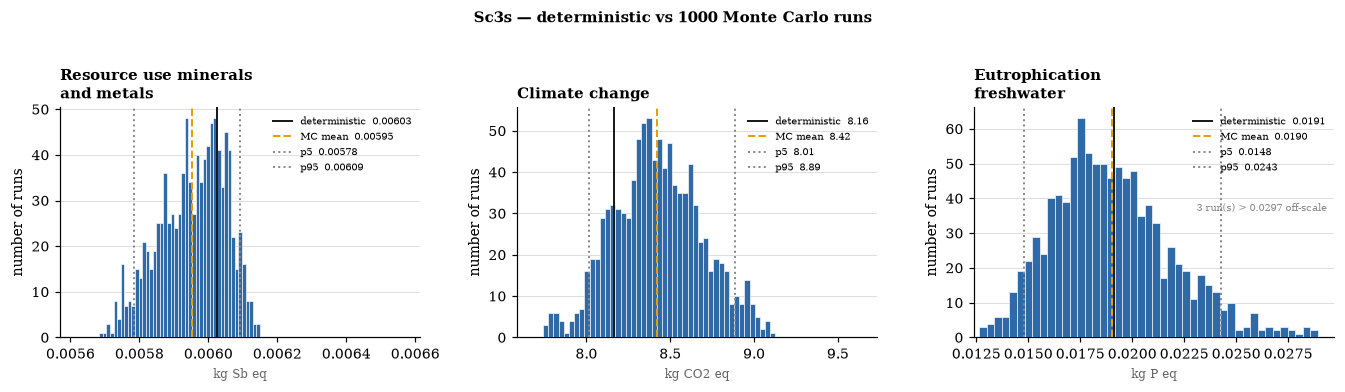

In [79]:
# --- Sc3s: deterministic vs Monte Carlo, all three reporting categories --------
# One panel per category. Each has its OWN x-axis: the three categories are in
# kg Sb eq / kg CO2 eq / kg P eq and differ by orders of magnitude, so a shared
# scale is impossible.
CATS_MC = REPORTING          # reorder here if you want a different panel order

if "Sc3s" in runs:
    cats = [c for c in CATS_MC if c in runs["Sc3s"]]

    fig, axes = plt.subplots(1, len(cats), figsize=(4.1 * len(cats), 3.4))
    axes = np.atleast_1d(axes)          # keeps zip() working if cats has 1 entry

    for ax, cat in zip(axes, cats):
        s = runs["Sc3s"][cat]
        # WIDE table: no .scenario/.category columns to filter on, and Sc3s's net
        # is the "Sc3s" column (landfill earns no credit, so net == gross == Sc3s).
        det_val = ef.loc[cat, "sc3_saving"]

        # Eutrophication has one draw at 2.19 kg P eq, ~8x its own p95, which
        # squashes the whole distribution into the left edge. Clip the axis at
        # p99 and say how many runs fall outside rather than hiding them.
        hi = max(s.quantile(.99), det_val, s.mean()) * 1.08
        shown = s[s <= hi]
        n_hidden = len(s) - len(shown)

        ax.hist(shown, bins=45, color=SC_COLOR["sc3"], edgecolor="white",
                linewidth=.4, zorder=3)
        ax.set_xlim(min(s.min(), det_val) * .98, hi)
        if n_hidden:
            ax.annotate(f"{n_hidden} run(s) > {sig(hi, 3)} off-scale",
                        (.98, .55), xycoords="axes fraction", ha="right",
                        fontsize=6.5, color="#8a8a8a")

        # sig(v, 3), not f"{v:.1f}": Resource use is ~0.0187, so .1f would
        # print "0.0" for every line in that panel.
        for val, color, lab, ls in (
            (det_val,         "#1a1a1a", f"deterministic  {sig(det_val, 3)}", "-"),
            (s.mean(),        AMBER,     f"MC mean  {sig(s.mean(), 3)}",      "--"),
            (s.quantile(.05), "#8a8a8a", f"p5  {sig(s.quantile(.05), 3)}",    ":"),
            (s.quantile(.95), "#8a8a8a", f"p95  {sig(s.quantile(.95), 3)}",   ":"),
        ):
            ax.axvline(val, color=color, ls=ls, lw=1.3, label=lab, zorder=4)

        ax.set_title(wrap(cat))
        # Units from UNIT (the impact CSV) -- runs[...].attrs["units"] only
        # exists on the xlsx-parsed frames, not the mc_raw_*.csv ones.
        ax.set_xlabel(UNIT[cat], fontsize=8, color="#666")
        ax.set_ylabel("number of runs")
        ax.legend(fontsize=6.5, loc="upper right")
        ax.grid(axis="x", visible=False)

    fig.suptitle(f"Sc3s — deterministic vs {len(runs['Sc3s'])} Monte Carlo runs",
                 x=0.5, y=1.03, fontsize=10, fontweight="bold")
    fig.tight_layout(w_pad=2.0)

    save(fig, "ef31_mc_distribution_Sc3s_all")
    plt.show()
else:
    print("Sc3s export not available yet — skipping.")

#### Deterministic vs Monte Carlo, Sc4

##### Deterministic vs Monte Carlo, Sc4 gross

In [81]:
if "Sc4g" in runs:
    det = ef["sc4_gross"]
    rows = []
    for c in REPORTING:
        if c in runs["Sc4g"]:
            s = runs["Sc4g"][c]
            rows.append({"category": c, "unit": UNIT[c],
                         "deterministic (mode-based)": det[c],
                         "MC mean": s.mean(),
                         #"MC median": s.median(),
                         "MC mean / deterministic": f"{s.mean() / det[c]:.4f}×",
                         #"MC p5": s.quantile(.05),
                         #"MC p95": s.quantile(.95)
                         })
    display(pd.DataFrame(rows))
else:
    print("Sc4g export not available yet.")

,category,unit,deterministic (mode-based),MC mean,MC mean / deterministic
0,Resource use minerals and metals,kg Sb eq,0.018740,0.018988,1.0132×
1,Climate change,kg CO2 eq,73.410318,93.494533,1.2736×
2,Eutrophication freshwater,kg P eq,0.115937,0.142824,1.2319×


saved: ef41_mc_distribution_Sc4g_all.png / .pdf


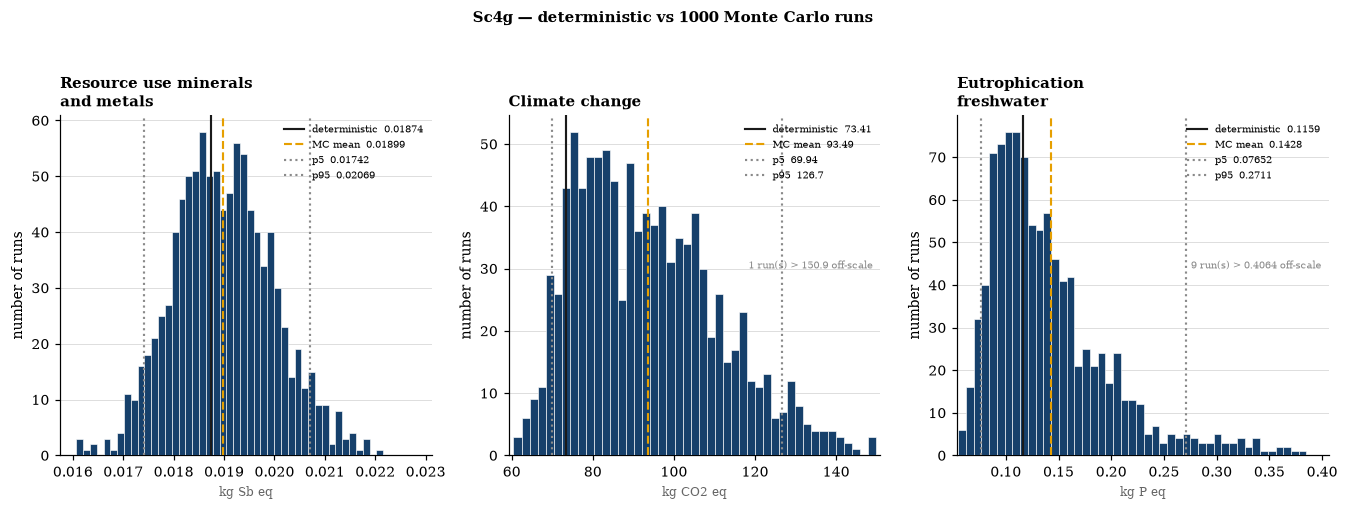

In [82]:
# --- Sc4g: deterministic vs Monte Carlo, all three reporting categories --------
# One panel per category. Each has its OWN x-axis: the three categories are in
# kg Sb eq / kg CO2 eq / kg P eq and differ by orders of magnitude, so a shared
# scale is impossible.
CATS_MC = REPORTING          # reorder here if you want a different panel order

if "Sc4g" in runs:
    cats = [c for c in CATS_MC if c in runs["Sc4g"]]

    fig, axes = plt.subplots(1, len(cats), figsize=(4.1 * len(cats), 4.4))
    axes = np.atleast_1d(axes)          # keeps zip() working if cats has 1 entry

    for ax, cat in zip(axes, cats):
        s = runs["Sc4g"][cat]
        # WIDE table: no .scenario/.category columns to filter on, and Sc4g's net
        # is the "Sc4g" column (landfill earns no credit, so net == gross == Sc4g).
        det_val = ef.loc[cat, "sc4_gross"]

        # Eutrophication has one draw at 2.19 kg P eq, ~8x its own p95, which
        # squashes the whole distribution into the left edge. Clip the axis at
        # p99 and say how many runs fall outside rather than hiding them.
        hi = max(s.quantile(.99), det_val, s.mean()) * 1.08
        shown = s[s <= hi]
        n_hidden = len(s) - len(shown)

        ax.hist(shown, bins=45, color=SC_COLOR["sc4"], edgecolor="white",
                linewidth=.4, zorder=4)
        ax.set_xlim(min(s.min(), det_val) * .98, hi)
        if n_hidden:
            ax.annotate(f"{n_hidden} run(s) > {sig(hi, 4)} off-scale",
                        (.98, .55), xycoords="axes fraction", ha="right",
                        fontsize=6.5, color="#8a8a8a")

        # sig(v, 4), not f"{v:.1f}": Resource use is ~0.0187, so .1f would
        # print "0.0" for every line in that panel.
        for val, color, lab, ls in (
            (det_val,         "#1a1a1a", f"deterministic  {sig(det_val, 4)}", "-"),
            (s.mean(),        AMBER,     f"MC mean  {sig(s.mean(), 4)}",      "--"),
            (s.quantile(.05), "#8a8a8a", f"p5  {sig(s.quantile(.05), 4)}",    ":"),
            (s.quantile(.95), "#8a8a8a", f"p95  {sig(s.quantile(.95), 4)}",   ":"),
        ):
            ax.axvline(val, color=color, ls=ls, lw=1.4, label=lab, zorder=4)

        ax.set_title(wrap(cat))
        # Units from UNIT (the impact CSV) -- runs[...].attrs["units"] only
        # exists on the xlsx-parsed frames, not the mc_raw_*.csv ones.
        ax.set_xlabel(UNIT[cat], fontsize=8, color="#666")
        ax.set_ylabel("number of runs")
        ax.legend(fontsize=6.5, loc="upper right")
        ax.grid(axis="x", visible=False)

    fig.suptitle(f"Sc4g — deterministic vs {len(runs['Sc4g'])} Monte Carlo runs",
                 x=0.5, y=1.04, fontsize=10, fontweight="bold")
    fig.tight_layout(w_pad=2.0)

    save(fig, "ef41_mc_distribution_Sc4g_all")
    plt.show()
else:
    print("Sc4g export not available yet — skipping.")


##### Deterministic vs Monte Carlo, Sc4 saving

In [83]:
if "Sc4s" in runs:
    det = ef["sc4_saving"]
    rows = []
    for c in REPORTING:
        if c in runs["Sc4s"]:
            s = runs["Sc4s"][c]
            rows.append({"category": c, "unit": UNIT[c],
                         "deterministic (mode-based)": det[c],
                         "MC mean": s.mean(),
                         #"MC median": s.median(),
                         "MC mean / deterministic": f"{s.mean() / det[c]:.4f}×",
                         #"MC p5": s.quantile(.05),
                         #"MC p95": s.quantile(.95)
                         })
    display(pd.DataFrame(rows))
else:
    print("Sc4s export not available yet.")

,category,unit,deterministic (mode-based),MC mean,MC mean / deterministic
0,Resource use minerals and metals,kg Sb eq,0.008870,0.008897,1.0030×
1,Climate change,kg CO2 eq,15.431529,15.845769,1.0268×
2,Eutrophication freshwater,kg P eq,0.029761,0.030057,1.0099×


saved: ef41_mc_distribution_Sc4s_all.png / .pdf


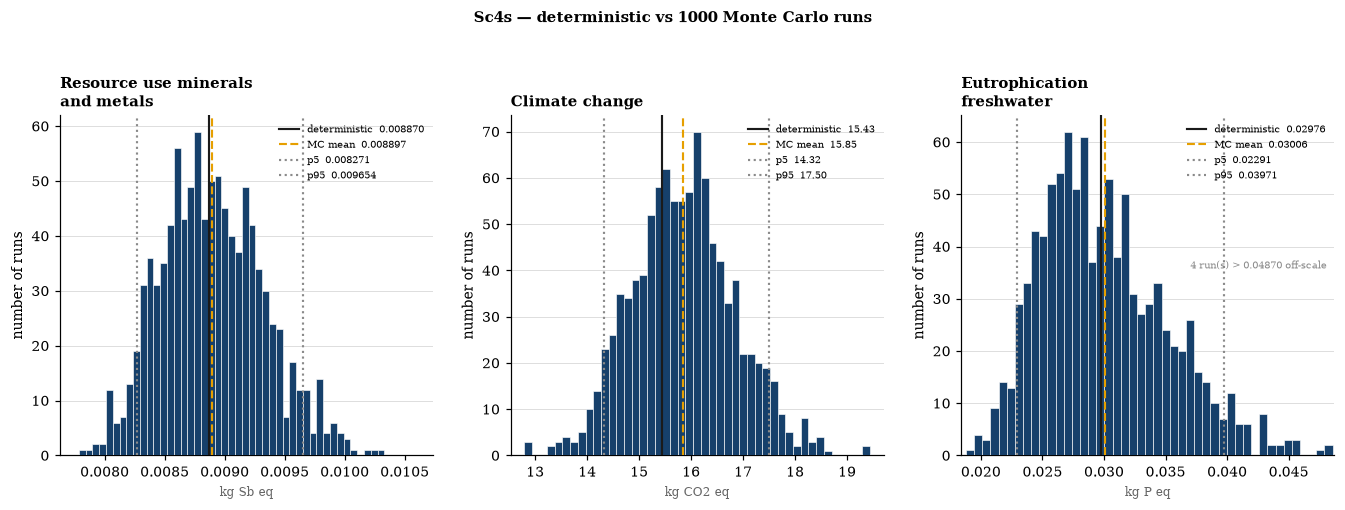

In [84]:
# --- Sc4s: deterministic vs Monte Carlo, all three reporting categories --------
# One panel per category. Each has its OWN x-axis: the three categories are in
# kg Sb eq / kg CO2 eq / kg P eq and differ by orders of magnitude, so a shared
# scale is impossible.
CATS_MC = REPORTING          # reorder here if you want a different panel order

if "Sc4s" in runs:
    cats = [c for c in CATS_MC if c in runs["Sc4s"]]

    fig, axes = plt.subplots(1, len(cats), figsize=(4.1 * len(cats), 4.4))
    axes = np.atleast_1d(axes)          # keeps zip() working if cats has 1 entry

    for ax, cat in zip(axes, cats):
        s = runs["Sc4s"][cat]
        # WIDE table: no .scenario/.category columns to filter on, and Sc4s's net
        # is the "Sc4s" column (landfill earns no credit, so net == gross == Sc4s).
        det_val = ef.loc[cat, "sc4_saving"]

        # Eutrophication has one draw at 2.19 kg P eq, ~8x its own p95, which
        # squashes the whole distribution into the left edge. Clip the axis at
        # p99 and say how many runs fall outside rather than hiding them.
        hi = max(s.quantile(.99), det_val, s.mean()) * 1.08
        shown = s[s <= hi]
        n_hidden = len(s) - len(shown)

        ax.hist(shown, bins=45, color=SC_COLOR["sc4"], edgecolor="white",
                linewidth=.4, zorder=4)
        ax.set_xlim(min(s.min(), det_val) * .98, hi)
        if n_hidden:
            ax.annotate(f"{n_hidden} run(s) > {sig(hi, 4)} off-scale",
                        (.98, .55), xycoords="axes fraction", ha="right",
                        fontsize=6.5, color="#8a8a8a")

        # sig(v, 4), not f"{v:.1f}": Resource use is ~0.0187, so .1f would
        # print "0.0" for every line in that panel.
        for val, color, lab, ls in (
            (det_val,         "#1a1a1a", f"deterministic  {sig(det_val, 4)}", "-"),
            (s.mean(),        AMBER,     f"MC mean  {sig(s.mean(), 4)}",      "--"),
            (s.quantile(.05), "#8a8a8a", f"p5  {sig(s.quantile(.05), 4)}",    ":"),
            (s.quantile(.95), "#8a8a8a", f"p95  {sig(s.quantile(.95), 4)}",   ":"),
        ):
            ax.axvline(val, color=color, ls=ls, lw=1.4, label=lab, zorder=4)

        ax.set_title(wrap(cat))
        # Units from UNIT (the impact CSV) -- runs[...].attrs["units"] only
        # exists on the xlsx-parsed frames, not the mc_raw_*.csv ones.
        ax.set_xlabel(UNIT[cat], fontsize=8, color="#666")
        ax.set_ylabel("number of runs")
        ax.legend(fontsize=6.5, loc="upper right")
        ax.grid(axis="x", visible=False)

    fig.suptitle(f"Sc4s — deterministic vs {len(runs['Sc4s'])} Monte Carlo runs",
                 x=0.5, y=1.04, fontsize=10, fontweight="bold")
    fig.tight_layout(w_pad=2.0)

    save(fig, "ef41_mc_distribution_Sc4s_all")
    plt.show()
else:
    print("Sc4s export not available yet — skipping.")

#### Spread across every simulated system

saved: ef31_mc_boxplot_by_system_all.png / .pdf


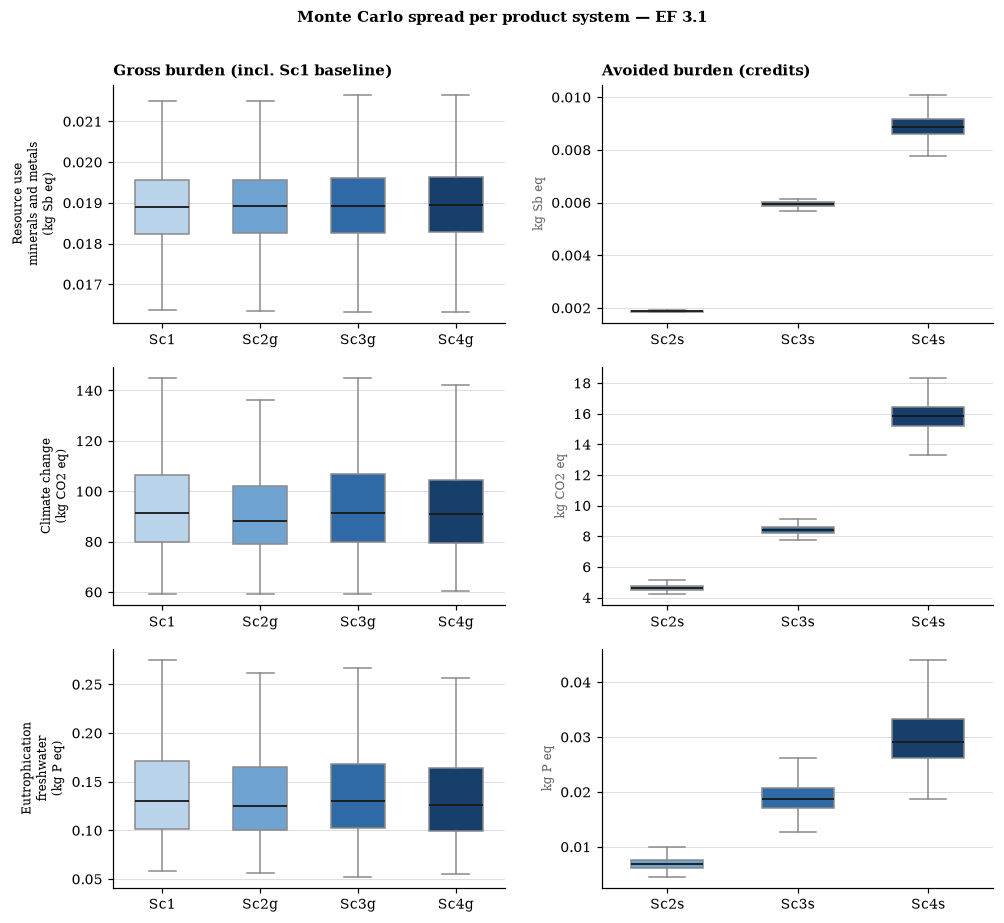

In [85]:
# --- Monte Carlo spread per product system, all reporting categories ---------
# Grid: one ROW per category, one COLUMN per system group (gross / credits).
# Each row has its own units, so every panel keeps its own y-scale.
if runs:
    gross_keys  = [k for k in SYSTEMS if k in runs and not k.endswith("s")]
    credit_keys = [k for k in SYSTEMS if k in runs and k.endswith("s")]

    cols = [(gross_keys, "Gross burden (incl. Sc1 baseline)"),
            (credit_keys, "Avoided burden (credits)")]
    cols = [c for c in cols if c[0]]
    cats = [c for c in REPORTING if any(c in runs[k] for k in runs)]

    # squeeze=False keeps axes 2-D even if a row or column drops out, so the
    # axes[i][j] indexing below never breaks.
    fig, axes = plt.subplots(len(cats), len(cols),
                             figsize=(4.6 * len(cols), 2.75 * len(cats)),
                             squeeze=False)

    for i, cat in enumerate(cats):
        for j, (keys, title) in enumerate(cols):
            ax = axes[i][j]
            ks = [k for k in keys if cat in runs[k]]

            # tick_labels=, not labels=: boxplot's `labels` was renamed in
            # matplotlib 3.9 and removed in 3.11 (this env runs 3.11.1).
            bp = ax.boxplot([runs[k][cat].values for k in ks], tick_labels=ks,
                            patch_artist=True, widths=.55, showfliers=False,
                            medianprops=dict(color="#1a1a1a", lw=1.2),
                            whiskerprops=dict(color="#8a8a8a"),
                            capprops=dict(color="#8a8a8a"))
            for patch, k in zip(bp["boxes"], ks):
                patch.set_facecolor(SC_COLOR.get(k[:3].lower(), "#c9d6e2"))
                patch.set_edgecolor("#8a8a8a")

            if i == 0:                      # column header on the top row only
                ax.set_title(title, fontsize=9.5)
            if j == 0:                      # category name labels the row
                ax.set_ylabel(f"{wrap(cat, 20)}\n({UNIT[cat]})", fontsize=8)
            else:
                ax.set_ylabel(UNIT[cat], fontsize=8, color="#666")
            ax.grid(axis="x", visible=False)

    # NOTE: every panel has an independent y-scale. Ranking within a panel is
    # readable; box heights across panels or columns are not comparable.
    fig.suptitle("Monte Carlo spread per product system — EF 3.1",
                 x=0.5, y=1.01, fontsize=10, fontweight="bold")
    fig.tight_layout(w_pad=2.0, h_pad=1.4)

    save(fig, "ef31_mc_boxplot_by_system_all")
    plt.show()
else:
    print("No Monte Carlo exports found yet.")


# **Impact ReCiPe**

ReCiPe answers exactly ONE question: "does the
conclusion survive a different method?" (robustness). Robustness is a
COMPARATIVE question, so every chart below is comparative or aggregate

In [101]:
rec_mid = pd.read_csv(BASE / "impact_ReCiPe_mid.csv")
rec_aop = pd.read_csv(BASE / "impact_ReCiPe_end_aop.csv")
rec_scr = pd.read_csv(BASE / "impact_screening_ReCiPe_mid.csv")
ef = pd.read_csv(BASE / "impact_EF31.csv")

In [102]:
def red_pct(df, cat_col="category"):
    """Sc2/Sc3/Sc4 net reduction vs Sc1, in %, indexed by category."""
    d = df.set_index(cat_col)
    return pd.DataFrame({s: 100 * (d[f"{s}_net"] - d["sc1"]) / d["sc1"]
                         for s in ("sc2", "sc3", "sc4")})

EF <-> ReCiPe category pairing. These are ANALOGOUS indicators, not identical ones: they share an environmental mechanism but differ in characterisation model and reference substance. That difference is the point of the comparison, so the pairing is declared explicitly rather than matched by fuzzy string.

In [103]:
PAIRS = [
    ("Climate change",                               "Global warming"),
    ("Resource use minerals and metals",             "Mineral resource scarcity"),
    ("Resource use fossils",                         "Fossil resource scarcity"),
    ("Acidification",                                "Terrestrial acidification"),
    ("Eutrophication freshwater",                    "Freshwater eutrophication"),
    ("Eutrophication marine",                        "Marine eutrophication"),
    ("Ecotoxicity freshwater",                       "Freshwater ecotoxicity"),
    ("Human toxicity cancer",                        "Human carcinogenic toxicity"),
    ("Human toxicity non-cancer",                    "Human non-carcinogenic toxicity"),
    ("Ionising radiation (human health)",            "Ionizing radiation"),
    ("Land use",                                     "Land use"),
    ("Ozone depletion",                              "Stratospheric ozone depletion"),
    ("Particulate matter",                           "Fine particulate matter formation"),
    ("Photochemical ozone formation (human health)", "Ozone formation, Human health"),
    ("Water use",                                    "Water consumption"),
]

### **Impact ReCiPe 2016 — method cross-check**

In [104]:
rec_mid 

,category,sc1,sc2_gross,sc2_saving,sc2_net,sc3_gross,sc3_saving,sc3_net,sc4_gross,sc4_saving,sc4_net,unit
0,Fine particulate matter formation,0.156472,0.156546,0.014694,0.141852,0.156507,0.028915,0.127592,0.156508,0.046537,0.109971,kg PM2.5 eq
1,Fossil resource scarcity,18.967480,18.975400,1.143638,17.831762,18.974139,2.159415,16.814725,18.974949,4.058109,14.916839,kg oil eq
2,Freshwater ecotoxicity,35.110021,35.107933,3.734656,31.373277,35.108903,10.957387,24.151516,35.108693,15.819795,19.288898,"kg 1,4-DCB"
3,Freshwater eutrophication,0.115922,0.115938,0.006899,0.109039,0.115932,0.019143,0.096789,0.115940,0.029762,0.086179,kg P eq
4,Global warming,74.399636,74.447065,4.472676,69.974390,74.376483,8.272683,66.103800,74.377512,15.666220,58.711292,kg CO2 eq
5,Human carcinogenic toxicity,9.322973,9.341842,1.378189,7.963653,9.389566,1.948454,7.441113,9.385745,2.497500,6.888245,"kg 1,4-DCB"
6,Human non-carcinogenic toxicity,575.318894,576.311834,58.274942,518.036893,579.618471,169.205699,410.412772,579.317630,246.559881,332.757749,"kg 1,4-DCB"
7,Ionizing radiation,10.658353,10.663839,0.503071,10.160768,10.665622,0.892398,9.773224,10.666204,1.678523,8.987681,kBq Co-60 eq
8,Land use,2.689218,2.689096,0.161881,2.527215,2.689711,0.415411,2.274300,2.689819,0.657957,2.031862,m2a crop eq
9,Marine ecotoxicity,46.568957,46.565767,4.883333,41.682434,46.566346,14.389119,32.177226,46.566065,20.797644,25.768421,"kg 1,4-DCB"


In [105]:
# ensure `ef` has a 'category' column and a 'unit' column so the cmp_ lookup works
ef = ef.reset_index()
ef["unit"] = ef["category"].map(UNIT)

# compute reductions (red_pct expects a DataFrame with a 'category' column)
ef_red  = red_pct(ef)
rec_red = red_pct(rec_mid.reset_index() if "category" not in rec_mid.columns else rec_mid)
cmp_ = pd.DataFrame(
    [{"ef_category": a, "recipe_category": b,
      "ef_unit":  ef.set_index("category").loc[a, "unit"],
      "rec_unit": rec_mid.set_index("category").loc[b, "unit"],
      "ef_sc4_pct":  ef_red.loc[a, "sc4"],
      "rec_sc4_pct": rec_red.loc[b, "sc4"]}
     for a, b in PAIRS])
cmp_["delta_pp"] = cmp_.rec_sc4_pct - cmp_.ef_sc4_pct
cmp_ = cmp_.sort_values("ef_sc4_pct")
print(f"mean |disagreement| = {cmp_.delta_pp.abs().mean():.1f} pp   "
      f"max = {cmp_.delta_pp.abs().max():.1f} pp "
      f"({cmp_.loc[cmp_.delta_pp.abs().idxmax(), 'ef_category']})")
cmp_.round(1)

mean |disagreement| = 3.2 pp   max = 13.2 pp (Eutrophication marine)


,ef_category,recipe_category,ef_unit,rec_unit,ef_sc4_pct,rec_sc4_pct,delta_pp
1,Resource use minerals and metals,Mineral resource scarcity,kg Sb eq,kg Cu eq,-47.3,-38.9,8.4
6,Ecotoxicity freshwater,Freshwater ecotoxicity,CTUe,"kg 1,4-DCB",-43.1,-45.1,-2.0
8,Human toxicity non-cancer,Human non-carcinogenic toxicity,CTUh,"kg 1,4-DCB",-39.5,-42.2,-2.7
12,Particulate matter,Fine particulate matter formation,disease incidence,kg PM2.5 eq,-34.8,-29.7,5.1
7,Human toxicity cancer,Human carcinogenic toxicity,CTUh,"kg 1,4-DCB",-34.4,-26.1,8.3
13,Photochemical ozone formation (human health),"Ozone formation, Human health",kg NMVOC eq,kg NOx eq,-30.7,-31.9,-1.1
5,Eutrophication marine,Marine eutrophication,kg N eq,kg N eq,-28.5,-15.3,13.2
3,Acidification,Terrestrial acidification,mol H+ eq,kg SO2 eq,-28.4,-28.0,0.4
4,Eutrophication freshwater,Freshwater eutrophication,kg P eq,kg P eq,-25.7,-25.7,0.0
10,Land use,Land use,dimensionless (pt),m2a crop eq,-25.3,-24.4,0.9


### R1 — Do the two methods agree? (the core robustness figure)
One row per paired indicator, showing the Sc4 net reduction under each method.
If the thesis conclusion is method-dependent, it shows up here as long
connectors. This is the figure that answers the supervisor's cross-check request.


saved: p3_01_method_agreement.png / .pdf


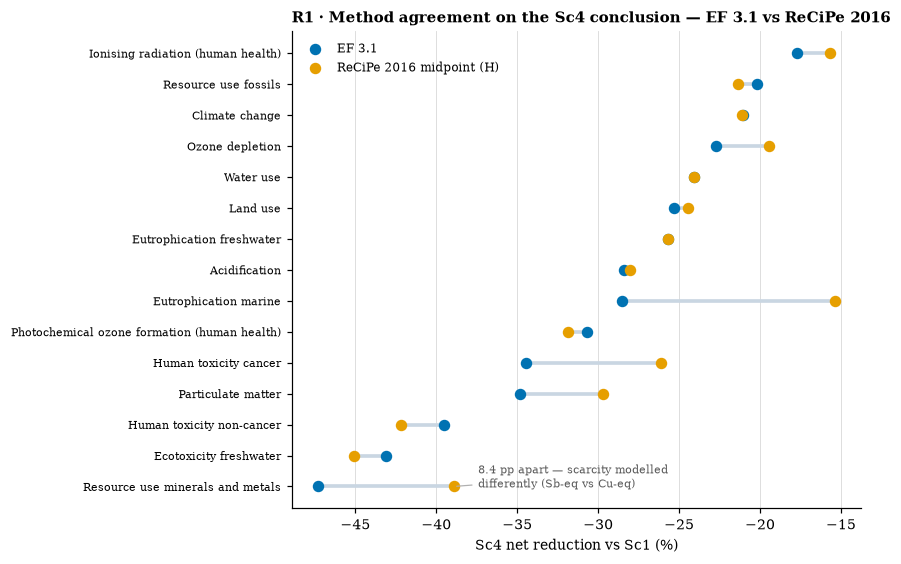

In [106]:
fig, ax = plt.subplots(figsize=(8, 5.2))
y = np.arange(len(cmp_))

# connector first, so the markers sit on top
ax.hlines(y, cmp_.ef_sc4_pct, cmp_.rec_sc4_pct, color="#c9d6e2", lw=2.4, zorder=1)
ax.scatter(cmp_.ef_sc4_pct,  y, s=42, color=BLUE,  zorder=3, label="EF 3.1")
ax.scatter(cmp_.rec_sc4_pct, y, s=42, color=AMBER, zorder=3, label="ReCiPe 2016 midpoint (H)")

# Call out minerals explicitly — it is the thesis-relevant indicator, and the gap
# is substantive rather than incidental (abiotic depletion in Sb-eq vs surplus ore
# in Cu-eq). Note this is NOT automatically the largest gap: marine eutrophication
# disagrees more, but on a category that carries no weight in the argument.
_m = cmp_.reset_index(drop=True)
_i = _m.index[_m.ef_category == "Resource use minerals and metals"][0]
_r = _m.loc[_i]
ax.annotate(f"{abs(_r.delta_pp):.1f} pp apart — scarcity modelled\ndifferently (Sb-eq vs Cu-eq)",
            (max(_r.ef_sc4_pct, _r.rec_sc4_pct), _i), (16, 6),
            textcoords="offset points", fontsize=7.5, color="#5a5a5a",
            va="center", ha="left",
            arrowprops=dict(arrowstyle="-", color="#b0b0b0", lw=.8))

ax.set_yticks(y); ax.set_yticklabels(cmp_.ef_category, fontsize=7.5)
ax.set_xlabel("Sc4 net reduction vs Sc1 (%)")
ax.set_title("R1 · Method agreement on the Sc4 conclusion — EF 3.1 vs ReCiPe 2016")
ax.legend(loc="upper left", fontsize=8)
ax.grid(axis="y", visible=False)
fig.tight_layout(); save(fig, "p3_01_method_agreement"); plt.show()

### R2 — Damage view: the three areas of protection
ReCiPe 2016 Endpoint reports damage in DALY, species·yr and USD2013. These are
summed within their native units and reported **as they are** — no
normalisation, no weighting, no single score (framework §4.2.1). Each panel has
its own axis because the units are not commensurable; that is the honest form.

saved: p3_02_endpoint_aop.png / .pdf


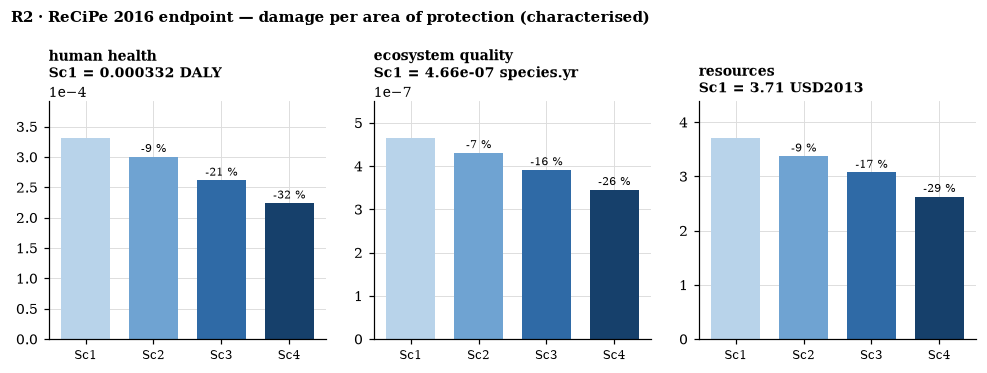

In [107]:
fig, axes = plt.subplots(1, 3, figsize=(9, 3.4))
for ax, (_, r) in zip(axes, rec_aop.iterrows()):
    vals = [r["sc1"], r["sc2_net"], r["sc3_net"], r["sc4_net"]]
    bars = ax.bar(range(4), vals, .72, color=[SC_COLOR[s] for s in SCEN])
    for i, (b, v) in enumerate(zip(bars, vals)):
        if i == 0: continue                      # Sc1 absolute goes in the title
        ax.annotate(f"{100*(v-vals[0])/vals[0]:+.0f} %",
                    (b.get_x() + b.get_width()/2, v), (0, 3),
                    textcoords="offset points", ha="center", fontsize=7.5)
    ax.set_xticks(range(4)); ax.set_xticklabels(["Sc1", "Sc2", "Sc3", "Sc4"], fontsize=8)
    ax.set_title(f"{r['area_of_protection']}\nSc1 = {vals[0]:.3g} {r['unit']}", fontsize=9)
    ax.set_ylim(0, max(vals) * 1.18)
    ax.ticklabel_format(axis="y", style="sci", scilimits=(-2, 3))
fig.suptitle("R2 · ReCiPe 2016 endpoint — damage per area of protection (characterised)",
             x=0.01, ha="left", fontsize=10, fontweight="bold")
fig.tight_layout(); save(fig, "p3_02_endpoint_aop"); plt.show()

saved: p3_03_normalisation_disjoint.png / .pdf


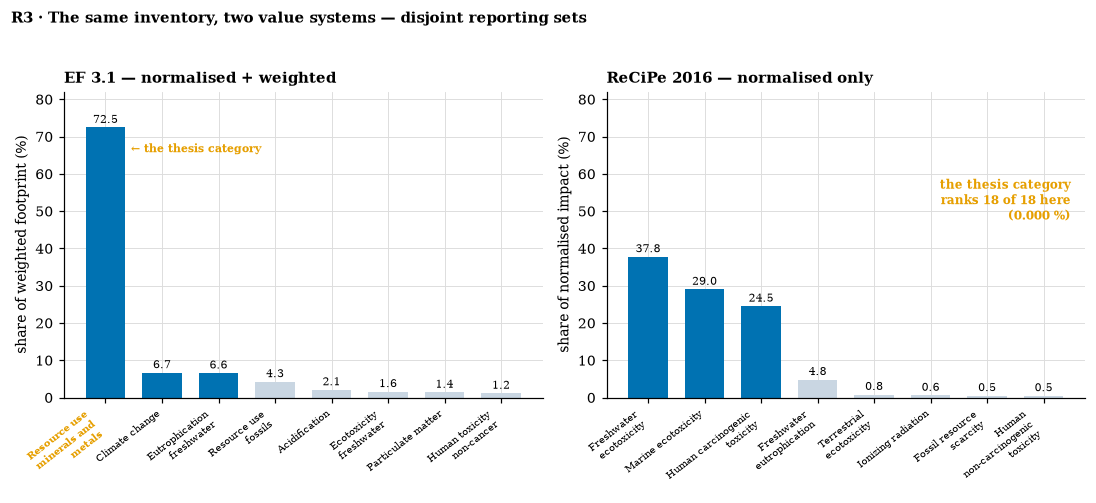

In [108]:
ef_s  = pd.read_csv(BASE / "impact_screening.csv").sort_values("share_pct", ascending=False)
rec_s = rec_scr.sort_values("share_pct", ascending=False)
for d, c in ((ef_s, "in_reporting_set"), (rec_s, "in_reporting_set")):
    if d[c].dtype == object:
        d[c] = d[c].astype(str).str.strip().str.lower() == "true"

TOP = 8                                   # bars shown per panel
PANELS = [
    (ef_s,  "Resource use minerals and metals", "EF 3.1 — normalised + weighted",
     "share of weighted footprint (%)"),
    (rec_s, "Mineral resource scarcity",        "ReCiPe 2016 — normalised only",
     "share of normalised impact (%)"),
]
fig, axes = plt.subplots(1, 2, figsize=(10, 4.6))
for ax, (full, key, ttl, ylab) in zip(axes, PANELS):
    d = full.head(TOP).reset_index(drop=True)
    x = np.arange(len(d))
    ax.bar(x, d.share_pct, .7, color=[BLUE if k else "#c9d6e2" for k in d.in_reporting_set])
    for xi, v in zip(x, d.share_pct):
        ax.annotate(f"{v:.1f}", (xi, v), (0, 3), textcoords="offset points",
                    ha="center", fontsize=7)
    ax.set_xticks(x)
    ax.set_xticklabels([wrap(c, 18) for c in d.category], rotation=38, ha="right", fontsize=6.8)
    ax.set_title(ttl); ax.set_ylabel(ylab); ax.set_ylim(0, 82)

    # Flag the thesis category. Highlighting the tick label avoids the arrow/title
    # collisions that come with annotating inside a panel this dense.
    hit = d.index[d.category == key]
    if len(hit):                                    # visible in the top-N
        t = ax.get_xticklabels()[hit[0]]
        t.set_color(AMBER); t.set_fontweight("bold")
        ax.annotate("← the thesis category", (hit[0] + 0.45, d.share_pct.iloc[hit[0]] * 0.92),
                    fontsize=7.5, color=AMBER, fontweight="bold", ha="left", va="center")
    else:                                           # ranks outside the top-N
        rank = int(full.reset_index(drop=True).index[full.reset_index(drop=True).category == key][0]) + 1
        share = float(full.loc[full.category == key, "share_pct"].iloc[0])
        ax.text(0.97, 0.72,
                f"the thesis category\nranks {rank} of {len(full)} here\n({share:.3f} %)",
                transform=ax.transAxes, ha="right", va="top",
                fontsize=8, color=AMBER, fontweight="bold")

fig.suptitle("R3 · The same inventory, two value systems — disjoint reporting sets",
             x=0.01, ha="left", fontsize=10, fontweight="bold")
fig.tight_layout(rect=(0, 0, 1, 0.95))
save(fig, "p3_03_normalisation_disjoint"); plt.show()

saved: p3_04_recipe_reduction_heatmap.png / .pdf


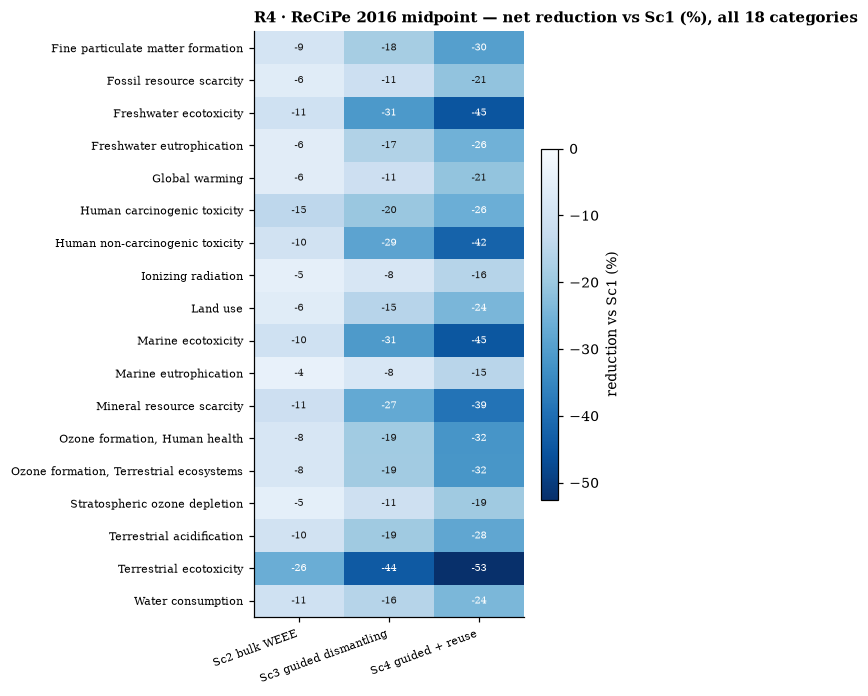

In [109]:
H = rec_red.loc[rec_mid.set_index("category").index]        # keep CSV order
fig, ax = plt.subplots(figsize=(5.6, 6.4))
im = ax.imshow(H.values, cmap="Blues_r", aspect="auto", vmin=H.values.min(), vmax=0)
ax.set_xticks(range(3)); ax.set_xticklabels([SC_NAME[s] for s in SCEN[1:]],
                                            rotation=20, ha="right", fontsize=7.5)
ax.set_yticks(range(len(H))); ax.set_yticklabels(H.index, fontsize=7)
for i in range(H.shape[0]):
    for j in range(H.shape[1]):
        v = H.values[i, j]
        ax.text(j, i, f"{v:.0f}", ha="center", va="center", fontsize=6.8,
                color="white" if v < H.values.min() * 0.45 else "#1a1a1a")
ax.set_title("R4 · ReCiPe 2016 midpoint — net reduction vs Sc1 (%), all 18 categories")
ax.grid(False)
fig.colorbar(im, ax=ax, shrink=.6, label="reduction vs Sc1 (%)")
fig.tight_layout(); save(fig, "p3_04_recipe_reduction_heatmap"); plt.show()

In [110]:
T1 = cmp_.assign(
        EF=lambda d: d.ef_sc4_pct.round(1).astype(str) + " %",
        ReCiPe=lambda d: d.rec_sc4_pct.round(1).astype(str) + " %",
        Δ=lambda d: d.delta_pp.round(1).astype(str) + " pp",
     )[["ef_category", "ef_unit", "EF", "recipe_category", "rec_unit", "ReCiPe", "Δ"]]
T1.columns = ["EF 3.1 category", "unit", "Sc4 red.",
              "ReCiPe 2016 category", "unit", "Sc4 red.", "difference"]
T1.to_csv(FIGS.parent / "table_T1_method_comparison.csv", index=False)
T1

,EF 3.1 category,unit,Sc4 red.,ReCiPe 2016 category,unit,Sc4 red.,difference
1,Resource use minerals and metals,kg Sb eq,-47.3 %,Mineral resource scarcity,kg Cu eq,-38.9 %,8.4 pp
6,Ecotoxicity freshwater,CTUe,-43.1 %,Freshwater ecotoxicity,"kg 1,4-DCB",-45.1 %,-2.0 pp
8,Human toxicity non-cancer,CTUh,-39.5 %,Human non-carcinogenic toxicity,"kg 1,4-DCB",-42.2 %,-2.7 pp
12,Particulate matter,disease incidence,-34.8 %,Fine particulate matter formation,kg PM2.5 eq,-29.7 %,5.1 pp
7,Human toxicity cancer,CTUh,-34.4 %,Human carcinogenic toxicity,"kg 1,4-DCB",-26.1 %,8.3 pp
13,Photochemical ozone formation (human health),kg NMVOC eq,-30.7 %,"Ozone formation, Human health",kg NOx eq,-31.9 %,-1.1 pp
5,Eutrophication marine,kg N eq,-28.5 %,Marine eutrophication,kg N eq,-15.3 %,13.2 pp
3,Acidification,mol H+ eq,-28.4 %,Terrestrial acidification,kg SO2 eq,-28.0 %,0.4 pp
4,Eutrophication freshwater,kg P eq,-25.7 %,Freshwater eutrophication,kg P eq,-25.7 %,0.0 pp
10,Land use,dimensionless (pt),-25.3 %,Land use,m2a crop eq,-24.4 %,0.9 pp


# **Impact ReCiPe EndPoint**

## Load the ReCiPe Endpoint impact table

In [91]:


rcpe = pd.read_csv(BASE / "impact_ReCiPe_end.csv")

UNIT = rcpe.set_index("category")["unit"]              # keep units aside
rcpe = rcpe.set_index("category").drop(columns="unit").astype(float)

print(f"{rcpe.shape[0]} categories x {rcpe.shape[1]} columns  <- {BASE / 'impact_ReCiPe_end.csv'}")
rcpe

22 categories x 10 columns  <- C:\Claude\Projects\AR_DPP\LCA_Analysis\Outputs\3_impact_assessment\impact_ReCiPe_end.csv


,sc1,sc2_gross,sc2_saving,sc2_net,sc3_gross,sc3_saving,sc3_net,sc4_gross,sc4_saving,sc4_net
category,,,,,,,,,,
Fine particulate matter formation,9.829478e-05,9.834137e-05,9.229367e-06,8.911200e-05,9.831707e-05,1.816349e-05,8.015359e-05,9.831756e-05,2.923802e-05,6.907954e-05
Fossil resource scarcity,3.204166e+00,3.205601e+00,2.842421e-01,2.921359e+00,3.206395e+00,5.021806e-01,2.704214e+00,3.206337e+00,8.881735e-01,2.318163e+00
Freshwater ecotoxicity,2.428892e-08,2.428748e-08,2.583623e-09,2.170386e-08,2.428816e-08,7.579972e-09,1.670819e-08,2.428802e-08,1.094366e-08,1.334436e-08
Freshwater eutrophication,7.763297e-08,7.764348e-08,4.620276e-09,7.302320e-08,7.763958e-08,1.282005e-08,6.481953e-08,7.764482e-08,1.993122e-08,5.771360e-08
"Global warming, Freshwater ecosystems",5.691194e-12,5.694822e-12,3.421324e-13,5.352690e-12,5.689423e-12,6.328044e-13,5.056619e-12,5.689502e-12,1.198368e-12,4.491134e-12
"Global warming, Human health",6.904649e-05,6.909050e-05,4.150767e-06,6.493973e-05,6.902500e-05,7.677234e-06,6.134776e-05,6.902595e-05,1.453919e-05,5.448676e-05
"Global warming, Terrestrial ecosystems",2.083485e-07,2.084813e-07,1.252535e-08,1.959560e-07,2.082837e-07,2.316684e-08,1.851168e-07,2.082866e-07,4.387360e-08,1.644130e-07
Human carcinogenic toxicity,3.094885e-05,3.101142e-05,4.575301e-06,2.643612e-05,3.116966e-05,6.468252e-06,2.470140e-05,3.115699e-05,8.290766e-06,2.286622e-05
Human non-carcinogenic toxicity,1.312179e-04,1.314438e-04,1.329026e-05,1.181536e-04,1.321967e-04,3.859411e-05,9.360256e-05,1.321282e-04,5.623858e-05,7.588959e-05
